In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.labels import LabelLoader
from src.loader import SimulationLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from config import SIM7200_DIR, LABEL_FILE, DATA_DIR, MIN_SEQUENCE_LEN

loader = SimulationLoader(SIM7200_DIR)
labels = LabelLoader(LABEL_FILE)


In [3]:
from pathlib import Path

filepath = SIM7200_DIR / "00002_balance_readable.xlsx"

print(filepath)
print("Exists:", filepath.exists())
print("Size:", filepath.stat().st_size, "bytes")

/home/ikeaprash/project/data/7200 sec Run/00002_balance_readable.xlsx
Exists: True
Size: 3476061 bytes


In [4]:
simid=43
sim = loader.load_simulation(simid)
print(labels.get_initial_conclusion(simid))
balance = sim["balance"]
temp = sim["temperature"]

/home/ikeaprash/project/data/7200 sec Run/00043_balance_readable.xlsx
Timed Out


In [72]:
label= labels.get_label(simid)

In [73]:
print(balance.shape)
print(temp.shape)
print(label)

(6023, 101)
(576096, 6)
Timed Out


In [74]:
balance.columns

Index(['time', 'dt', 'mg', 'mgd', 'ml', 'mld', 'mp', 'mpd', 'mm', 'mmd',
       ...
       'errmg', 'errmli', 'errml', 'erregi', 'erreg', 'erreli', 'errel',
       'errepi', 'errep', 'm(Corium)'],
      dtype='object', length=101)

In [75]:
balance.head()

,time,dt,mg,mgd,ml,mld,mp,mpd,mm,mmd,...,errmg,errmli,errml,erregi,erreg,erreli,errel,errepi,errep,m(Corium)
0,0.00100,0.00100,11.12229,0.02831,215521.47,8793.1099,249897.77,0,0,0,...,-0.02831,-0.01992,-19.92208,0.10975,109.74827,-12778.208,-1.277821e+07,-0.02477,-24.77304,249897.77
1,1.00887,0.00818,69.27136,34.17926,179863.55,-38665.9570,249897.77,0,0,0,...,0.00289,-5.05519,-0.49856,-538.52627,212.67986,-79742.626,-3.173260e+03,816.14218,26.25384,249897.77
2,2.00993,0.02593,82.42360,4.85536,155959.60,-10925.3110,249897.77,0,0,0,...,0.00986,-18.13653,-0.03589,314.04269,-539.12349,-73241.471,-3.794455e+02,781.79131,958.33587,249897.77
3,3.02239,0.06576,84.82070,-1.10321,151694.18,1141.4598,249897.77,0,0,0,...,0.00067,-30.38216,1.08928,-1416.20960,-4876.76760,-64901.812,4.771204e+03,1466.16350,2838.40460,249897.77
4,4.16573,0.16362,82.98825,-1.72054,154012.54,2355.9027,249897.77,0,0,0,...,-0.01063,-23.61128,0.17427,-6380.28510,2073.60450,-61191.972,2.208341e+02,2857.36120,-1622.55260,249897.77


In [76]:
balance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6023 entries, 0 to 6022
Columns: 101 entries, time to m(Corium)
dtypes: float64(42), int64(59)
memory usage: 4.6 MB


In [77]:
balance.describe()

,time,dt,mg,mgd,ml,mld,mp,mpd,mm,mmd,...,errmg,errmli,errml,erregi,erreg,erreli,errel,errepi,errep,m(Corium)
count,6023.000000,6023.000000,6023.000000,6023.000000,6023.000000,6023.000000,6.023000e+03,6023.0,6023.0,6023.0,...,6023.000000,6023.000000,6023.000000,6.023000e+03,6023.000000,6.023000e+03,6.023000e+03,6.023000e+03,6023.000000,6.023000e+03
mean,3654.962254,0.399835,69.037054,0.000530,192038.042414,1.058378,2.498978e+05,0.0,0.0,0.0,...,-0.003420,-629.138242,-0.215961,-9.842264e+06,-2166.285229,-6.617733e+06,-3.641864e+03,4.810431e+06,1065.616420,2.498978e+05
std,2084.998741,0.254883,3.465722,0.493861,4053.890842,541.910967,5.821249e-11,0.0,0.0,0.0,...,0.010412,544.015528,2.227854,4.505720e+06,4276.422001,3.130101e+06,1.655091e+05,2.387881e+06,2289.949211,5.821249e-11
min,0.001000,0.001000,11.122290,-3.845870,151694.180000,-38665.957000,2.498978e+05,0.0,0.0,0.0,...,-0.156060,-1530.276600,-66.898480,-1.574936e+07,-39333.041000,-9.514872e+06,-1.277821e+07,-2.477000e-02,-10938.612000,2.498978e+05
25%,1848.108350,0.245360,66.613240,-0.028745,191015.665000,-3.263170,2.498978e+05,0.0,0.0,0.0,...,-0.007785,-1032.103150,-0.374615,-1.383408e+07,-4423.070600,-8.821353e+06,-1.422106e+04,3.038313e+06,-226.412965,2.498978e+05
50%,3633.115700,0.330660,67.408140,-0.001090,192937.300000,1.101200,2.498978e+05,0.0,0.0,0.0,...,-0.002730,-758.122860,-0.079540,-1.042403e+07,-2015.966500,-7.950978e+06,-1.576449e+03,4.900645e+06,943.020010,2.498978e+05
75%,5504.118700,0.454660,70.951730,0.012285,194602.050000,15.542985,2.498978e+05,0.0,0.0,0.0,...,0.002140,-112.218130,0.004750,-7.065723e+06,388.935355,-5.578406e+06,1.121988e+04,7.230931e+06,2192.781750,2.498978e+05
max,7199.761000,2.412810,99.056390,34.179260,215521.470000,8793.109900,2.498978e+05,0.0,0.0,0.0,...,0.066510,305.310840,43.120010,3.140427e+02,17708.147000,1.135520e+06,7.304387e+04,7.872805e+06,23638.011000,2.498978e+05


In [78]:
temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576096 entries, 0 to 576095
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   time         576096 non-null  float64
 1   particle_id  576096 non-null  int64  
 2   x            576096 non-null  float64
 3   y            576096 non-null  float64
 4   z            576096 non-null  float64
 5   temperature  576096 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 26.4 MB


In [79]:
temp.head()

,time,particle_id,x,y,z,temperature
0,0.001,0,0.04839,0.0,0.01177,815.87
1,0.001,1,0.14520,0.0,0.01177,815.87
2,0.001,2,0.24210,0.0,0.01177,815.87
3,0.001,3,0.33910,0.0,0.01177,815.87
4,0.001,4,0.43620,0.0,0.01177,815.87


In [80]:
temp.describe()

,time,particle_id,x,y,z,temperature
count,576096.000000,576096.000000,576096.000000,576096.0,576096.000000,576096.000000
mean,3608.967386,407.500000,1.502514,0.0,0.597830,609.355886
std,2080.352003,235.558937,0.928541,0.0,0.532987,320.073908
min,0.001000,0.000000,0.048390,0.0,0.011770,416.041000
25%,1808.940000,203.750000,0.728900,0.0,0.159100,417.196000
50%,3605.880000,407.500000,1.420000,0.0,0.399650,417.387000
75%,5415.680000,611.250000,2.216000,0.0,1.049000,848.531000
max,7198.010000,815.000000,3.301000,0.0,1.884000,1909.960000


In [81]:
labels.get_row(simid)

Psys                     356519.0
Ffuel                     0.65285
Porosity                 0.256275
Dparticle                0.003211
Alpha                      32.055
Rflat                      1.2714
Tbed                       815.87
Decay                    0.006865
Fstruct                  1.817125
Rcake                    0.679942
Topcake                  1.174191
Botcake                  0.854754
Porcake                  0.144731
Partdiacake               0.00249
Hdebris                  1.947316
Conclusion              Timed Out
Quenching Time                NaN
Timed Out Conclusion    Timed Out
Name: 43, dtype: object

In [82]:
print(balance.columns.tolist())

['time', 'dt', 'mg', 'mgd', 'ml', 'mld', 'mp', 'mpd', 'mm', 'mmd', 'mc', 'mcd', 'md', 'mdd', 'mlay', 'mlayd', 'eg', 'egd', 'el', 'eld', 'ep', 'epd', 'ec', 'ecd', 'em', 'emd', 'ed', 'edd', 'elay', 'elayd', 'fgini', 'fgin', 'fgouti', 'fgout', 'flini', 'flin', 'flouti', 'flout', 'fdini', 'fdin', 'fdouti', 'fdout', 'flayini', 'flayin', 'flayouti', 'flayout', 'qgini', 'qgin', 'qgouti', 'qgout', 'qlini', 'qlin', 'qlouti', 'qlout', 'qpini', 'qpin', 'qpouti', 'qpout', 'qdini', 'qdin', 'qdouti', 'qdout', 'qlayini', 'qlayin', 'qlayouti', 'qlayout', 'gevi', 'gev', 'qsii', 'qsi', 'qgii', 'qgi', 'qlii', 'qli', 'qsgi', 'qsg', 'qsli', 'qsl', 'qdti', 'qdt', 'qdri', 'qdr', 'qdii', 'qdi', 'qdgi', 'qdg', 'qlaytopi', 'qlaytop', 'powi', 'pow', 'errmgi', 'errmg', 'errmli', 'errml', 'erregi', 'erreg', 'erreli', 'errel', 'errepi', 'errep', 'm(Corium)']


In [83]:
print(balance["egd"]+ balance["eld"] + balance["epd"])


0       5.194017e+09
1      -2.265577e+10
2      -6.459002e+09
3       6.010211e+08
4       1.310505e+09
            ...     
6018   -4.949513e+05
6019   -5.822619e+05
6020   -2.461608e+06
6021   -1.461563e+06
6022   -1.601916e+06
Length: 6023, dtype: float64


In [84]:

print(sim.keys())

dict_keys(['id', 'balance', 'temperature'])


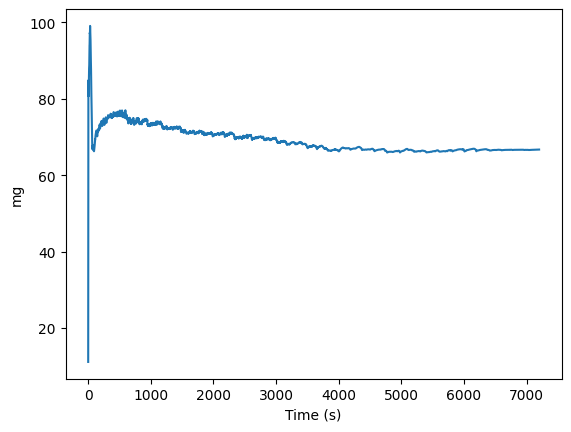

In [85]:
import matplotlib.pyplot as plt

plt.plot(balance["time"], balance["mg"])
plt.xlabel("Time (s)")
plt.ylabel("mg")
plt.show()

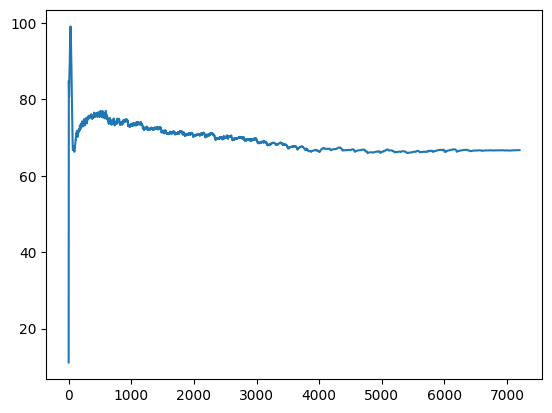

In [86]:
plt.plot(balance["time"], balance["mg"])

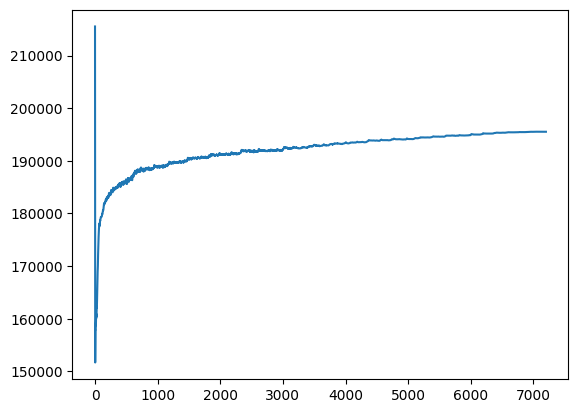

In [87]:
plt.plot(balance["time"], balance["ml"])

time
0.0010       815.870000
10.1739      813.712587
20.1869      811.756012
30.4423      809.734029
40.6916      808.074690
                ...    
7157.4800    507.747309
7167.6500    507.635150
7177.8400    507.523212
7187.9400    507.412254
7198.0100    507.299683
Name: temperature, Length: 706, dtype: float64


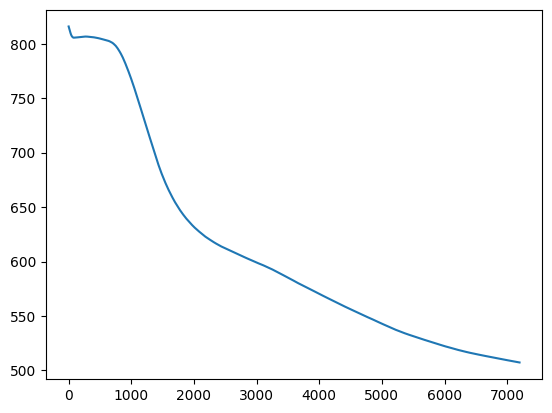

In [88]:
avg_temp = (
    temp.groupby("time")["temperature"]
        .mean()
)
print(avg_temp)
plt.plot(avg_temp.index, avg_temp.values)

In [89]:
from config import SIM7200_DIR, LABEL_FILE
loader = SimulationLoader(SIM7200_DIR)
labels = LabelLoader(LABEL_FILE)
df = labels.data()

print(df.head())
print(df.columns)

                   Psys    Ffuel  Porosity  Dparticle   Alpha   Rflat  \
Simulation No                                                           
0              404411.0  0.82635  0.486025   0.003924  16.839  0.5230   
1              148571.0  0.86185  0.258825   0.002791  18.597  1.8034   
2              411275.0  0.91785  0.423075   0.003737  16.203  0.3646   
3              457139.0  0.97545  0.442825   0.002564  21.129  0.1818   
4              380153.0  0.93225  0.334175   0.001651  27.843  1.0550   

                  Tbed     Decay   Fstruct     Rcake   Topcake   Botcake  \
Simulation No                                                              
0              1512.67  0.008307  1.115375  0.122930  0.715806  0.488859   
1              1253.71  0.007041  0.844125  1.142793  0.853430  0.716177   
2              1549.33  0.003242  0.550125  0.248922  1.254117  0.696887   
3              1286.47  0.007395  0.576375  0.185108  0.592630  0.413072   
4               488.53  0.003832

In [90]:
print(df.columns.tolist())
for c in df.columns:
    print(c)

['Psys', 'Ffuel', 'Porosity', 'Dparticle', 'Alpha', 'Rflat', 'Tbed', 'Decay', 'Fstruct', 'Rcake', 'Topcake', 'Botcake', 'Porcake', 'Partdiacake', 'Hdebris', 'Conclusion', 'Quenching Time', 'Timed Out Conclusion']
Psys
Ffuel
Porosity
Dparticle
Alpha
Rflat
Tbed
Decay
Fstruct
Rcake
Topcake
Botcake
Porcake
Partdiacake
Hdebris
Conclusion
Quenching Time
Timed Out Conclusion


In [91]:
print(balance.columns.tolist())
print(temp.columns.tolist())

['time', 'dt', 'mg', 'mgd', 'ml', 'mld', 'mp', 'mpd', 'mm', 'mmd', 'mc', 'mcd', 'md', 'mdd', 'mlay', 'mlayd', 'eg', 'egd', 'el', 'eld', 'ep', 'epd', 'ec', 'ecd', 'em', 'emd', 'ed', 'edd', 'elay', 'elayd', 'fgini', 'fgin', 'fgouti', 'fgout', 'flini', 'flin', 'flouti', 'flout', 'fdini', 'fdin', 'fdouti', 'fdout', 'flayini', 'flayin', 'flayouti', 'flayout', 'qgini', 'qgin', 'qgouti', 'qgout', 'qlini', 'qlin', 'qlouti', 'qlout', 'qpini', 'qpin', 'qpouti', 'qpout', 'qdini', 'qdin', 'qdouti', 'qdout', 'qlayini', 'qlayin', 'qlayouti', 'qlayout', 'gevi', 'gev', 'qsii', 'qsi', 'qgii', 'qgi', 'qlii', 'qli', 'qsgi', 'qsg', 'qsli', 'qsl', 'qdti', 'qdt', 'qdri', 'qdr', 'qdii', 'qdi', 'qdgi', 'qdg', 'qlaytopi', 'qlaytop', 'powi', 'pow', 'errmgi', 'errmg', 'errmli', 'errml', 'erregi', 'erreg', 'erreli', 'errel', 'errepi', 'errep', 'm(Corium)']
['time', 'particle_id', 'x', 'y', 'z', 'temperature']


## Energy Balance Investigation

To better understand the behavior of the simulations near the end of the transient, an overall energy balance was investigated. Based on discussions with the project supervisor, the following balance equation is expected to hold:

egd + eld + epd =
(qlout - qlin) + (qpout - qpin) + (qgout - qgin) - Power

where:

- `egd`, `eld`, `epd` represent the rate of change of internal energy of the gas, liquid, and particle phases.
- `qlout`, `qlin`, `qpout`, `qpin`, `qgout`, `qgin` are the heat fluxes entering and leaving the computational domain.
- `pow` is the imposed decay heat.

### Residual Definition

The residual of the energy balance was evaluated as

```python
balance["residual"] = (
    balance["energy_rate"]
    - balance["heat_balance"]
)
```

where

```python
balance["energy_rate"] = (
    balance["egd"]
    + balance["eld"]
    + balance["epd"]
)

balance["heat_balance"] = (
    (balance["qlout"] - balance["qlin"])
    + (balance["qpout"] - balance["qpin"])
    + (balance["qgout"] - balance["qgin"])
    - balance["pow"]
)
```

### Observations

The residual exhibits three distinct regions:

- A large transient during the initial timesteps.
- A gradual reduction in magnitude as the simulation progresses.
- Small fluctuations during the final stage of the simulation.

The large residual at the beginning is expected since the system is initially far from equilibrium. As the transient decays, the residual decreases significantly, indicating that the energy balance becomes increasingly well satisfied.

The final 1000 timesteps were analysed separately.

| Statistic | Residual |
|-----------|---------:|
| Mean | -2.34 × 10⁶ |
| Standard deviation | 3.26 × 10⁶ |
| Minimum | -1.45 × 10⁷ |
| Maximum | 2.82 × 10⁷ |

Although the residual is not exactly zero, its magnitude is considerably smaller than the characteristic energy terms, which are typically of the order of 10⁷–10⁸ W. This behaviour is consistent with the expected numerical error associated with a transient simulation approaching a quasi-steady state.

### Additional observations

- The decay heat (`pow`) remains constant throughout the simulation at approximately **1.72 × 10⁷ W**.
- No gas enters the domain (`qgin = 0`).
- No particles enter or leave the domain (`qpin = qpout = 0`).
- The dominant heat transfer mechanisms are therefore:
  - liquid heat transfer (`qlout`, `qlin`)
  - gas heat leaving the system (`qgout`)
  - the constant decay heat source (`pow`)

### Conclusion

The energy balance residual decreases substantially after the initial transient and remains bounded during the later stages of the simulation. This suggests that the numerical solution approaches a quasi-steady regime, although small residual fluctuations remain due to the transient nature of the simulation and numerical discretization.

The energy balance residual, together with its statistical properties over the final portion of the simulation, is a promising candidate for feature engineering in the machine learning model.

In [ ]:
balance["energy_rate"] = (
    balance["egd"]
    + balance["eld"]
    + balance["epd"]
)

balance["heat_balance"] = (
     balance["pow"]- (balance["qlin"] - balance["qlout"])
    + (balance["qpin"] - balance["qpout"])
    + (balance["qgout"] - balance["qgin"])
    
)

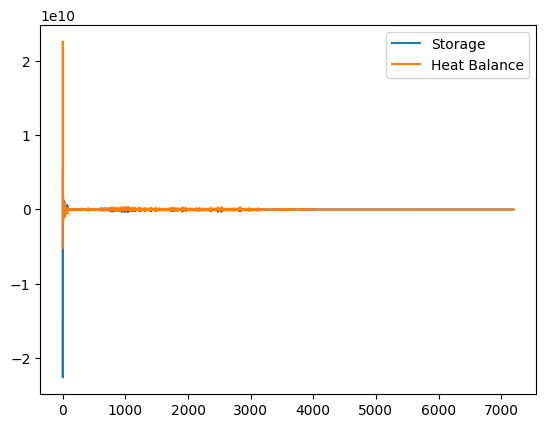

In [181]:
plt.plot(balance["time"], balance["energy_rate"], label="Storage")

plt.plot(balance["time"], balance["heat_balance"], label="Heat Balance")

plt.legend()

## Inference
- the Storage (blue) and Heat Balance (orange) curves almost completely overlap after the initial transient
- theres a very large spike at the beginning (~t=0)
- after that, both the quantities decay and fluctuate close to 0

### Reasoning
- initally, the system adjusts rapidly to the imposed conditions
- later, the rate of energy accumulation becomes much smaller

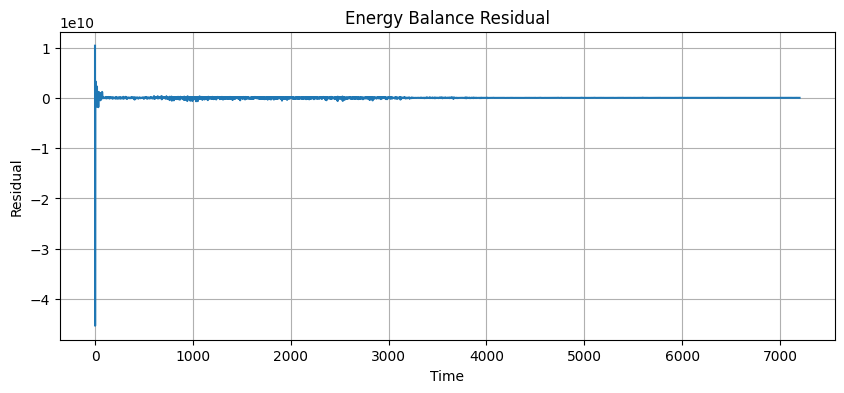

In [182]:
balance["residual1"] = (
    balance["energy_rate"]
    - balance["heat_balance"]
)


plt.figure(figsize=(10,4))
plt.plot(balance["time"], balance["residual1"])
plt.xlabel("Time")
plt.ylabel("Residual")
plt.title("Energy Balance Residual")
plt.grid(True)
plt.show()

In [183]:
print(balance["residual1"].describe())



count    6.023000e+03
mean    -1.041334e+07
std      6.346532e+08
min     -4.531167e+10
25%     -1.229703e+07
50%     -4.339507e+06
75%      6.278057e+06
max      1.036015e+10
Name: residual1, dtype: float64


In [ ]:
tail = balance.tail(1000)

print(tail["residual1"].describe())


count    1.000000e+03
mean    -2.342698e+06
std      3.255950e+06
min     -1.448910e+07
25%     -4.145493e+06
50%     -2.362586e+06
75%     -6.922801e+05
max      2.821135e+07
Name: residual1, dtype: float64
count    1.000000e+03
mean     3.403993e+05
std      2.116652e+05
min      8.562530e+04
25%      2.069393e+05
50%      2.608202e+05
75%      4.020279e+05
max      1.643525e+06
Name: residual2, dtype: float64


## Reasoning to the residual plot trend:
-  we have <i>residual= (storage)- (Heat Balance) </i>, which is close to zero for almost the entire simulation
- the only noticable deviations are during the very early transient

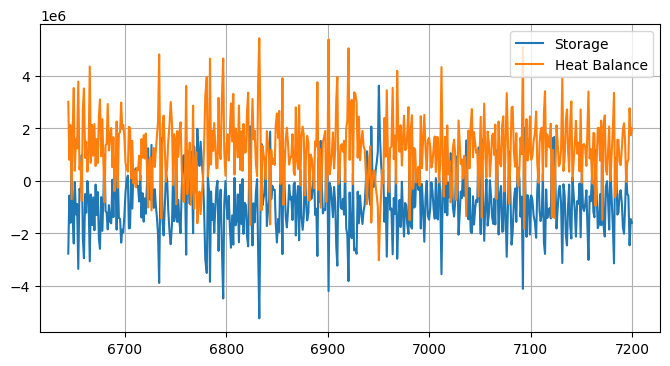

In [185]:
tail = balance.tail(500)

plt.figure(figsize=(8,4))
plt.plot(tail["time"], tail["energy_rate"], label="Storage")
plt.plot(tail["time"], tail["heat_balance"], label="Heat Balance")
plt.legend()
plt.grid(True)

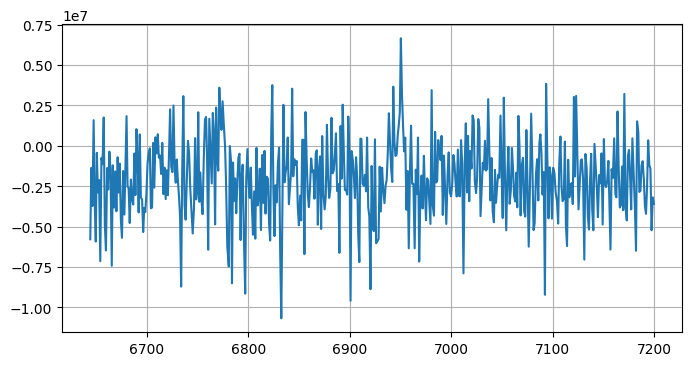

In [186]:
plt.figure(figsize=(8,4))
plt.plot(tail["time"], tail["residual1"])
plt.grid(True)

In [168]:
r1 = balance["energy_rate"] - balance["heat_balance"]
r2 = balance["energy_rate"] + balance["heat_balance"]

print("r1")
print(r1.tail(1000).describe())

print("\nr2")
print(r2.tail(1000).describe())

r1
count    1.000000e+03
mean    -2.342698e+06
std      3.255950e+06
min     -1.448910e+07
25%     -4.145493e+06
50%     -2.362586e+06
75%     -6.922801e+05
max      2.821135e+07
dtype: float64

r2
count    1.000000e+03
mean     3.403993e+05
std      2.116652e+05
min      8.562530e+04
25%      2.069393e+05
50%      2.608202e+05
75%      4.020279e+05
max      1.643525e+06
dtype: float64


In [132]:
tail = balance.tail(10)

In [133]:
a=tail["energy_rate"].sum()
print(a)


-12038109.7882


In [134]:
(tail["energy_rate"]).std()



np.float64(822707.7895845692)

In [135]:
tail["imbalance"].std()

np.float64(57122415.28697357)

In [136]:
tail["imbalance"].sum()

np.float64(-1237026323601.0)

In [137]:
b=tail["imbalance"].sum()
print(b)

-1237026323601.0


In [138]:
print(a-b)

1237014285491.212


In [167]:
storage = (
    balance["egd"]
    + balance["eld"]
    + balance["epd"]
)

heat = (
    balance["qlout"] - balance["qlin"]
    + balance["qpout"] - balance["qpin"]
    + balance["qgout"] - balance["qgin"]
    - balance["pow"]
)

print(storage.corr(heat))

-0.9999910748521744


In [147]:
r1 = storage - heat

r2 = storage + heat

r3 = storage - (
    heat + 2*balance["pow"]
)

r4 = storage + (
    heat + 2*balance["pow"]
)

In [148]:
print(r1,r2,r3,r4)

0       1.036015e+10
1      -4.531167e+10
2      -1.291794e+10
3       1.202694e+09
4       2.621078e+09
            ...     
6018   -1.190303e+06
6019   -1.397484e+06
6020   -5.223323e+06
6021   -3.193670e+06
6022   -3.592888e+06
Length: 6023, dtype: float64 0       2.788325e+07
1       1.279376e+05
2      -6.036520e+04
3      -6.516341e+05
4      -6.802360e+04
            ...     
6018    2.004007e+05
6019    2.329601e+05
6020    3.001072e+05
6021    2.705441e+05
6022    3.890556e+05
Length: 6023, dtype: float64 0       1.032576e+10
1      -4.534606e+10
2      -1.295233e+10
3       1.168306e+09
4       2.586690e+09
            ...     
6018   -3.557777e+07
6019   -3.578495e+07
6020   -3.961079e+07
6021   -3.758113e+07
6022   -3.798035e+07
Length: 6023, dtype: float64 0       6.227071e+07
1       3.451540e+07
2       3.432710e+07
3       3.373583e+07
4       3.431944e+07
            ...     
6018    3.458786e+07
6019    3.462042e+07
6020    3.468757e+07
6021    3.465801e+07
6022    3.

In [149]:
print(balance["pow"].describe())

print(balance["qgout"].describe())
print(balance["qgin"].describe())

print(balance["qlout"].describe())
print(balance["qlin"].describe())

print(balance["qpout"].describe())
print(balance["qpin"].describe())

count        6023.0
mean     17193732.0
std             0.0
min      17193732.0
25%      17193732.0
50%      17193732.0
75%      17193732.0
max      17193732.0
Name: pow, dtype: float64
count    6.023000e+03
mean     2.904857e+07
std      7.306728e+06
min      0.000000e+00
25%      2.533094e+07
50%      2.865965e+07
75%      3.096052e+07
max      1.086042e+08
Name: qgout, dtype: float64
count    6023.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: qgin, dtype: float64
count    6.023000e+03
mean     2.657355e+07
std      3.049836e+08
min      0.000000e+00
25%      1.604766e+07
50%      1.946720e+07
75%      2.009769e+07
max      2.267780e+10
Name: qlout, dtype: float64
count    6.023000e+03
mean     3.305842e+07
std      8.456361e+07
min      4.707097e+06
25%      2.265415e+07
50%      2.512348e+07
75%      3.031093e+07
max      5.148940e+09
Name: qlin, dtype: float64
count    6023.0
mean        0.0
std         0.0


In [170]:
storage = (
    balance["egd"]
    + balance["eld"]
    + balance["epd"]
)

heat = (
    balance["qlout"] - balance["qlin"]
    + balance["qpout"] - balance["qpin"]
    + balance["qgout"] - balance["qgin"]
    - balance["pow"]
)

relative_error = (
    (storage - heat).abs()
    / np.maximum(np.abs(storage), 1.0)
)

print(relative_error.describe())

count    6023.000000
mean        2.287913
std         5.883569
min         0.012364
25%         1.984382
50%         2.023029
75%         2.101194
max       368.760326
dtype: float64


In [153]:
tail = relative_error.tail(500)

print(tail.describe())

count    500.000000
mean       1.505576
std        9.886128
min        0.035492
25%        0.192314
50%        0.301088
75%        0.579300
max      166.722381
dtype: float64


In [42]:
import pandas as pd

metadata = pd.read_csv(
    DATA_DIR/"processed/simulation_metadata_7200.csv"
)

metadata.head()

,Simulation No,Psys,Ffuel,Porosity,Dparticle,Alpha,Rflat,Tbed,Decay,Fstruct,Rcake,Topcake,Botcake,Porcake,Partdiacake,Hdebris,sequence_length,maximum_time
0,0,404411.0,0.82635,0.486025,0.003924,16.839,0.5230,1512.67,0.008307,1.115375,0.122930,0.715806,0.488859,0.182432,0.000844,2.192350,213,2159.540
1,1,148571.0,0.86185,0.258825,0.002791,18.597,1.8034,1253.71,0.007041,0.844125,1.142793,0.853430,0.716177,0.223470,0.001861,1.336405,587,6033.240
2,2,411275.0,0.91785,0.423075,0.003737,16.203,0.3646,1549.33,0.003242,0.550125,0.248922,1.254117,0.696887,0.103698,0.003160,1.846595,712,7198.980
3,3,457139.0,0.97545,0.442825,0.002564,21.129,0.1818,1286.47,0.007395,0.576375,0.185108,0.592630,0.413072,0.305848,0.000449,2.250654,245,2493.700
4,4,380153.0,0.93225,0.334175,0.001651,27.843,1.0550,488.53,0.003832,1.301575,0.436180,0.513966,0.466557,0.079846,0.000250,2.334949,90,914.861


In [43]:
metadata.shape

(5000, 18)

In [44]:
metadata.describe().T

,count,mean,std,min,25%,50%,75%,max
Simulation No,5000.0,2499.500000,1443.520003,0.000000,1249.750000,2499.500000,3749.250000,4999.000000
Psys,5000.0,305000.000000,112594.560259,110039.000000,207519.500000,305000.000000,402480.500000,499961.000000
Ffuel,5000.0,0.750000,0.144352,0.500050,0.625025,0.750000,0.874975,0.999950
Porosity,5000.0,0.375000,0.072176,0.250025,0.312512,0.375000,0.437488,0.499975
Dparticle,5000.0,0.003000,0.001155,0.001000,0.002000,0.003000,0.004000,0.005000
Alpha,5000.0,30.000000,8.661120,15.003000,22.501500,30.000000,37.498500,44.997000
Rflat,5000.0,1.000000,0.577408,0.000200,0.500100,1.000000,1.499900,1.999800
Tbed,5000.0,1050.000000,375.315201,400.130000,725.065000,1050.000000,1374.935000,1699.870000
Decay,5000.0,0.006500,0.002021,0.003001,0.004750,0.006500,0.008250,0.009999
Fstruct,5000.0,1.125000,0.505232,0.250175,0.687588,1.125000,1.562412,1.999825


In [45]:
metadata.isna().sum()

Simulation No      0
Psys               0
Ffuel              0
Porosity           0
Dparticle          0
Alpha              0
Rflat              0
Tbed               0
Decay              0
Fstruct            0
Rcake              0
Topcake            0
Botcake            0
Porcake            0
Partdiacake        0
Hdebris            0
sequence_length    0
maximum_time       0
dtype: int64

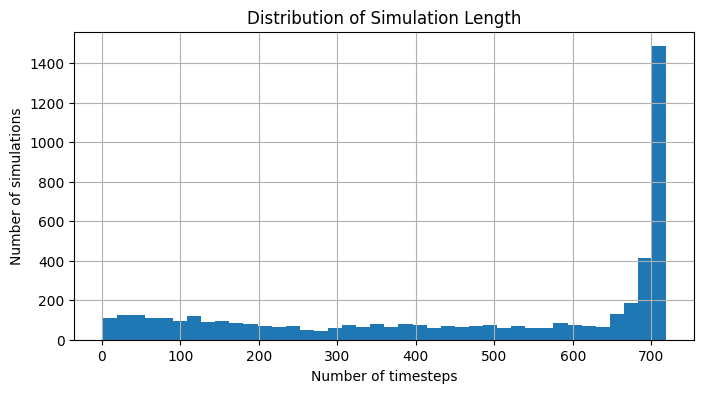

In [46]:
plt.figure(figsize=(8, 4))

plt.hist(
    metadata["sequence_length"],
    bins=40
)

plt.xlabel("Number of timesteps")
plt.ylabel("Number of simulations")
plt.title("Distribution of Simulation Length")

plt.grid(True)
plt.show()

In [47]:
metadata["sequence_length"].describe()

count    5000.000000
mean      472.337200
std       250.800104
min         1.000000
25%       228.000000
50%       578.000000
75%       706.000000
max       719.000000
Name: sequence_length, dtype: float64

In [48]:
metadata["sequence_length"].sort_values().head(20)

990     1
4825    1
62      1
1598    1
509     1
113     1
4766    1
1609    1
3272    1
2859    1
2808    1
941     1
2661    1
971     1
4007    1
3244    1
2536    1
1313    1
3745    1
2626    1
Name: sequence_length, dtype: int64

we see a bunch of simulation lengths only being 1, we now need to investigate how this works so that we can find a cutoff length for our model and remove those simulations that span shorter than the cutoff

In [49]:
#count of simulations with length less than 1,5,10, and 20
print("Total simulations:", len(metadata))

print("\nSequence length <= 1:")
print((metadata["sequence_length"] <= 1).sum())

print("\nSequence length <= 5:")
print((metadata["sequence_length"] <= 5).sum())

print("\nSequence length <= 10:")
print((metadata["sequence_length"] <= 10).sum())

print("\nSequence length <= 20:")
print((metadata["sequence_length"] <= 20).sum())

Total simulations: 5000

Sequence length <= 1:
39

Sequence length <= 5:
42

Sequence length <= 10:
63

Sequence length <= 20:
120


In [50]:
#find those simulations
short_cases = metadata[
    metadata["sequence_length"] <= 10
][
    [
        "Simulation No",
        "sequence_length",
        "maximum_time"
    ]
].sort_values("sequence_length")

short_cases.head(30)

,Simulation No,sequence_length,maximum_time
62,62,1,0.001
113,113,1,0.001
241,241,1,0.001
270,270,1,0.001
509,509,1,0.001
331,331,1,0.001
807,807,1,0.001
568,568,1,0.001
848,848,1,0.001
849,849,1,0.001


In [51]:
metadata[
    metadata["sequence_length"] <= 5
][
    ["Simulation No", "sequence_length", "maximum_time"]
].sort_values("sequence_length")

,Simulation No,sequence_length,maximum_time
62,62,1,0.0010
113,113,1,0.0010
241,241,1,0.0010
270,270,1,0.0010
331,331,1,0.0010
509,509,1,0.0010
568,568,1,0.0010
807,807,1,0.0010
849,849,1,0.0010
829,829,1,0.0010


In [52]:
import numpy as np

metadata["log_sequence_length"] = np.log1p(
    metadata["sequence_length"]
)

metadata["length_group"] = pd.qcut(
    metadata["log_sequence_length"],
    q=5,
    labels=False,
    duplicates="drop"
)

metadata["length_group"].value_counts().sort_index()

length_group
0    1000
1    1002
2    1001
3     997
4    1000
Name: count, dtype: int64

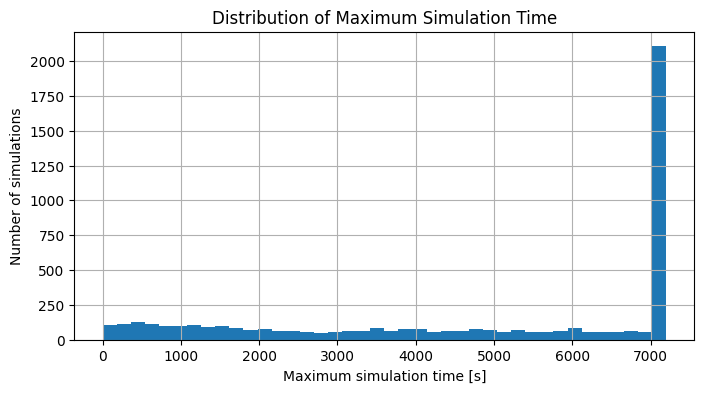

In [53]:
plt.figure(figsize=(8, 4))

plt.hist(
    metadata["maximum_time"],
    bins=40
)

plt.xlabel("Maximum simulation time [s]")
plt.ylabel("Number of simulations")
plt.title("Distribution of Maximum Simulation Time")

plt.grid(True)
plt.show()

In [54]:
metadata[
    ["sequence_length", "maximum_time"]
].describe()

,sequence_length,maximum_time
count,5000.000000,5000.000000
mean,472.337200,4828.713466
std,250.800104,2569.218419
min,1.000000,0.001000
25%,228.000000,2325.295000
50%,578.000000,5874.625000
75%,706.000000,7194.082500
max,719.000000,7200.000000


In [55]:
print(
    "Simulations reaching maximum time:",
    (metadata["maximum_time"] == metadata["maximum_time"].max()).sum()
)

print(
    "Simulations stopping earlier:",
    (metadata["maximum_time"] < metadata["maximum_time"].max()).sum()
)

Simulations reaching maximum time: 61
Simulations stopping earlier: 4939


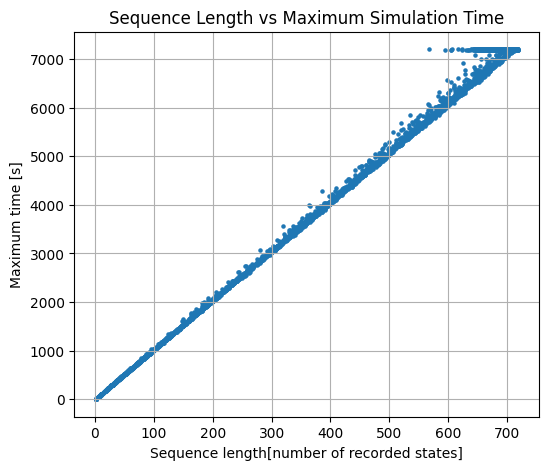

In [56]:
plt.figure(figsize=(6, 5))

plt.scatter(
    metadata["sequence_length"],
    metadata["maximum_time"],
    s=5
)

plt.xlabel("Sequence length[number of recorded states]")
plt.ylabel("Maximum time [s]")
plt.title("Sequence Length vs Maximum Simulation Time")

plt.grid(True)
plt.show()

In [57]:
metadata_clean[
    ["sequence_length", "maximum_time"]
].corr()

NameError: name 'metadata_clean' is not defined

In [41]:
plt.figure(figsize=(8, 5))

plt.scatter(
    metadata_clean["sequence_length"],
    metadata_clean["maximum_time"],
    alpha=0.4
)

plt.xlabel("Sequence length [number of states]")
plt.ylabel("Maximum simulation time [s]")
plt.title("Sequence Length vs Maximum Simulation Time")

plt.grid(True)
plt.show()

NameError: name 'metadata_clean' is not defined

<Figure size 800x500 with 0 Axes>

## 1. check input ranges

In [40]:
input_columns = [
    "Psys",
    "Ffuel",
    "Porosity",
    "Dparticle",
    "Alpha",
    "Rflat",
    "Tbed",
    "Decay",
    "Fstruct",
    "Rcake",
    "Topcake",
    "Botcake",
    "Porcake",
    "Partdiacake",
    "Hdebris",
]

metadata[input_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Psys,5000.0,305000.000000,112594.560259,110039.000000,207519.500000,305000.000000,402480.500000,499961.000000
Ffuel,5000.0,0.750000,0.144352,0.500050,0.625025,0.750000,0.874975,0.999950
Porosity,5000.0,0.375000,0.072176,0.250025,0.312512,0.375000,0.437488,0.499975
Dparticle,5000.0,0.003000,0.001155,0.001000,0.002000,0.003000,0.004000,0.005000
Alpha,5000.0,30.000000,8.661120,15.003000,22.501500,30.000000,37.498500,44.997000
Rflat,5000.0,1.000000,0.577408,0.000200,0.500100,1.000000,1.499900,1.999800
Tbed,5000.0,1050.000000,375.315201,400.130000,725.065000,1050.000000,1374.935000,1699.870000
Decay,5000.0,0.006500,0.002021,0.003001,0.004750,0.006500,0.008250,0.009999
Fstruct,5000.0,1.125000,0.505232,0.250175,0.687588,1.125000,1.562412,1.999825
Rcake,5000.0,0.550718,0.358044,0.001711,0.260775,0.488434,0.787456,2.036996


In [41]:
metadata[input_columns].nunique().sort_values()

Psys           5000
Ffuel          5000
Porosity       5000
Dparticle      5000
Alpha          5000
Rflat          5000
Tbed           5000
Decay          5000
Fstruct        5000
Rcake          5000
Topcake        5000
Botcake        5000
Porcake        5000
Partdiacake    5000
Hdebris        5000
dtype: int64

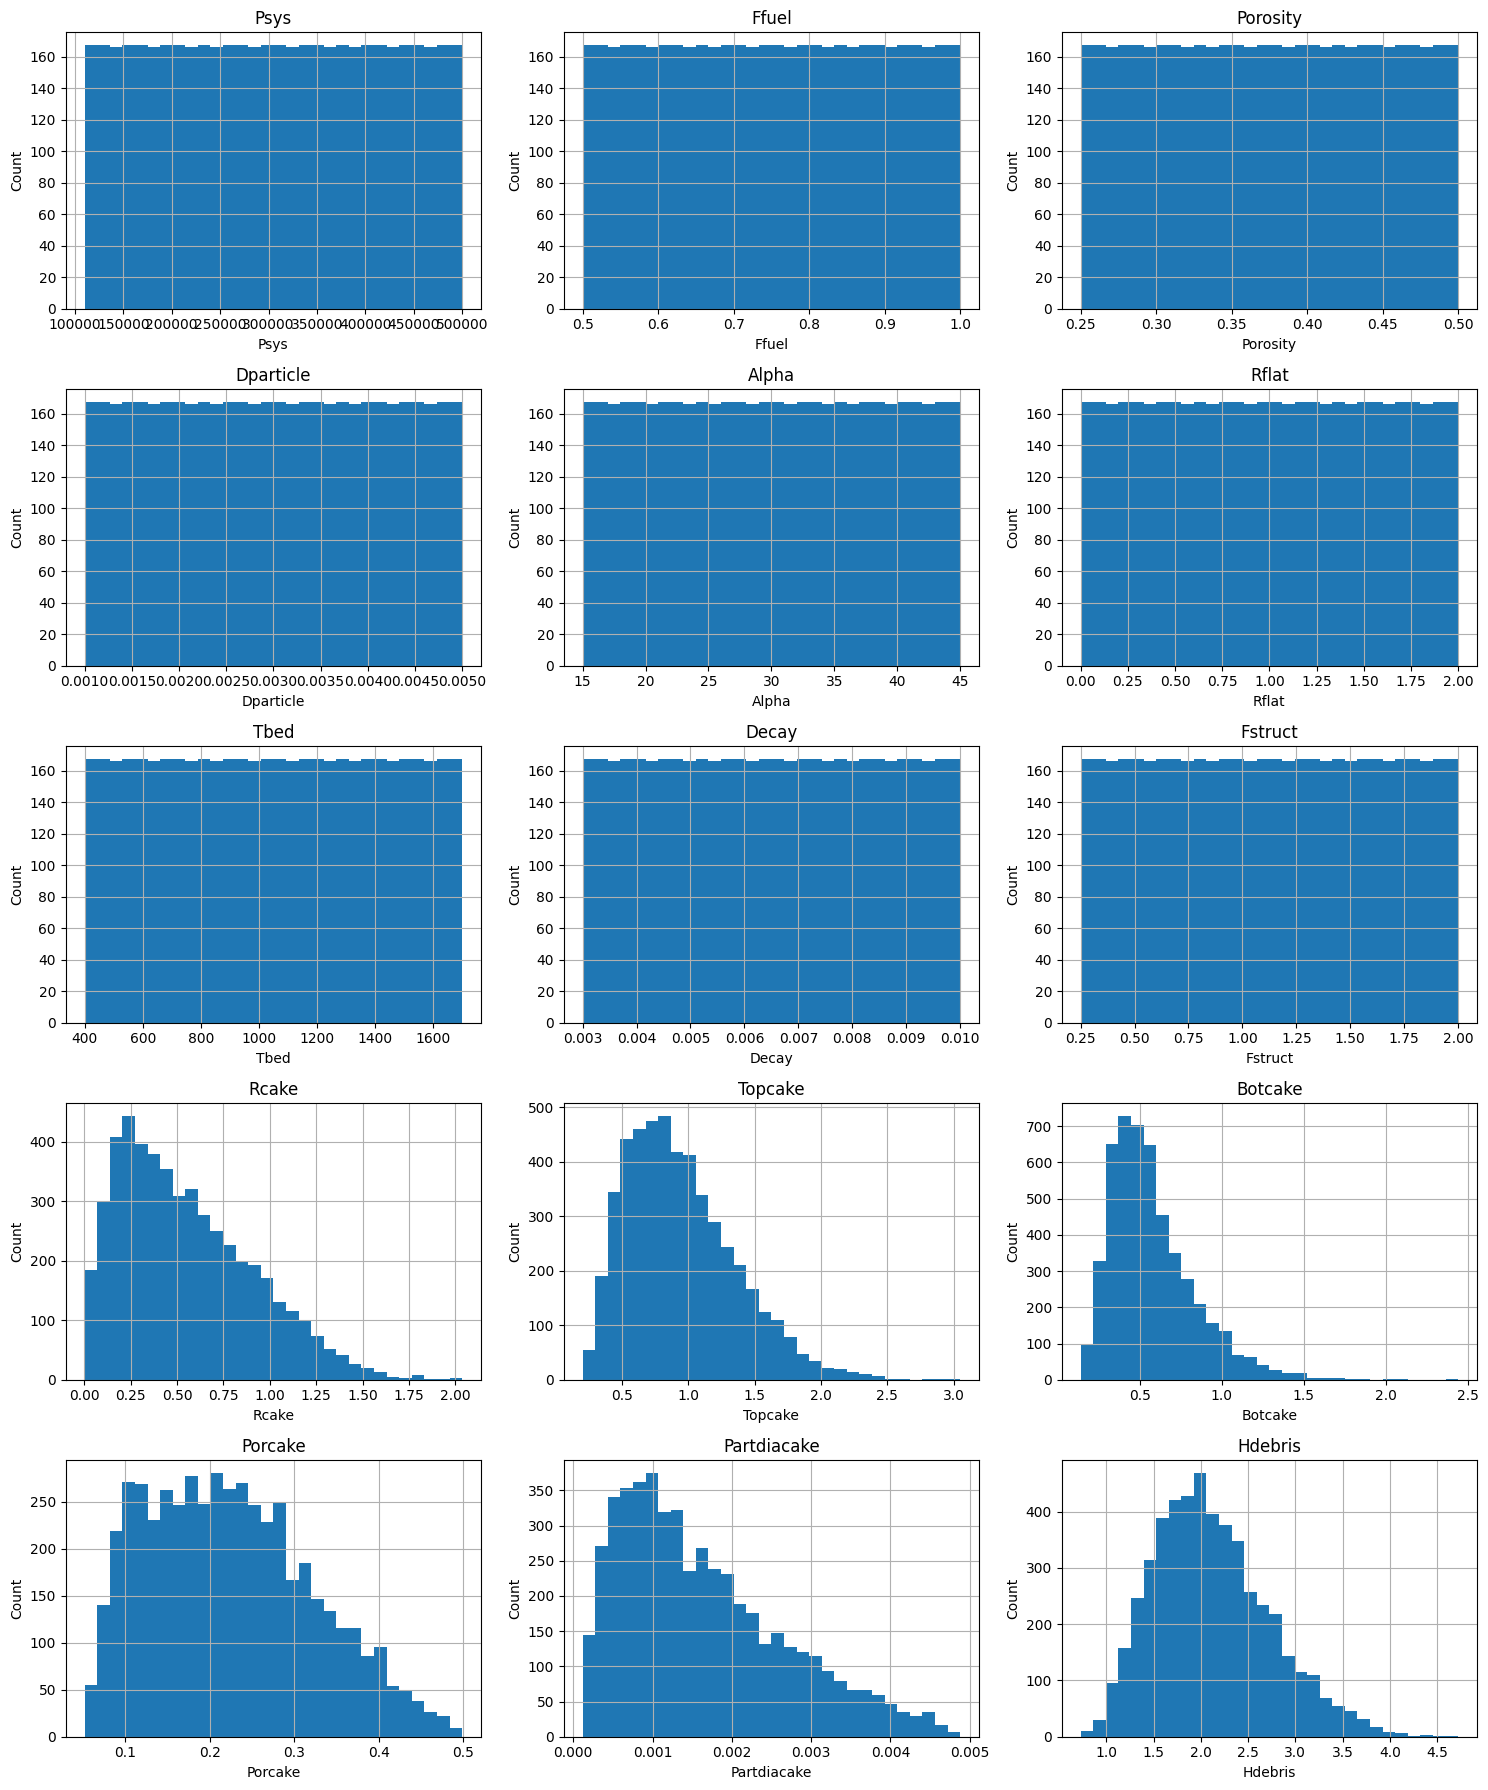

In [42]:
fig, axes = plt.subplots(
    5, 3,
    figsize=(15, 18)
)

for ax, column in zip(axes.flat, input_columns):

    ax.hist(
        metadata[column],
        bins=30
    )

    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel("Count")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Input Parameter Distribution

The 5000 simulations cover a 15-dimensional input parameter space. All 15 parameters contain 5000 unique values, indicating that none of the input parameters is constant across the dataset.

The distributions of the input parameters are not identical. Several parameters, including Psys, Ffuel, Porosity, Dparticle, Alpha, Rflat, Tbed, Decay, and Fstruct, are approximately uniformly distributed over their respective ranges. In contrast, several debris-bed and cake-related parameters, particularly Rcake, Topcake, Botcake, Partdiacake, and Hdebris, exhibit non-uniform distributions with varying degrees of skewness.

This indicates that the simulation dataset provides broad coverage of the input parameter space, although the sampling density is not uniform for all parameters. The non-uniform distributions should be considered when constructing the training, validation, and test sets to ensure that the model is evaluated across the relevant range of physical conditions.

In [44]:
metadata["time_per_step"] = (
    metadata["maximum_time"] /
    metadata["sequence_length"]
)

metadata["time_per_step"].describe()

count    5000.000000
mean       10.122302
std         0.923964
min         0.001000
25%        10.105197
50%        10.155861
75%        10.240535
max        12.670282
Name: time_per_step, dtype: float64

In [45]:
simid = 0
sim = loader.load_simulation(simid)

balance = sim["balance"]
temperature = sim["temperature"]

print(balance.shape)
print(temperature.shape)

/home/ikeaprash/project/data/7200 sec Run/00000_balance_readable.xlsx
(1879, 101)
(171678, 6)


In [47]:
print(balance.columns.tolist())
print(temperature.columns.tolist())

['time', 'dt', 'mg', 'mgd', 'ml', 'mld', 'mp', 'mpd', 'mm', 'mmd', 'mc', 'mcd', 'md', 'mdd', 'mlay', 'mlayd', 'eg', 'egd', 'el', 'eld', 'ep', 'epd', 'ec', 'ecd', 'em', 'emd', 'ed', 'edd', 'elay', 'elayd', 'fgini', 'fgin', 'fgouti', 'fgout', 'flini', 'flin', 'flouti', 'flout', 'fdini', 'fdin', 'fdouti', 'fdout', 'flayini', 'flayin', 'flayouti', 'flayout', 'qgini', 'qgin', 'qgouti', 'qgout', 'qlini', 'qlin', 'qlouti', 'qlout', 'qpini', 'qpin', 'qpouti', 'qpout', 'qdini', 'qdin', 'qdouti', 'qdout', 'qlayini', 'qlayin', 'qlayouti', 'qlayout', 'gevi', 'gev', 'qsii', 'qsi', 'qgii', 'qgi', 'qlii', 'qli', 'qsgi', 'qsg', 'qsli', 'qsl', 'qdti', 'qdt', 'qdri', 'qdr', 'qdii', 'qdi', 'qdgi', 'qdg', 'qlaytopi', 'qlaytop', 'powi', 'pow', 'errmgi', 'errmg', 'errmli', 'errml', 'erregi', 'erreg', 'erreli', 'errel', 'errepi', 'errep', 'm(Corium)']
['time', 'particle_id', 'x', 'y', 'z', 'temperature']


In [52]:
print(balance.head())
print(balance.describe().T)

      time       dt         mg        mgd          ml         mld         mp  \
0  0.00100  0.00100   17.71120    0.35583  198871.960  13398.9430  236371.72   
1  1.00324  0.00522  246.91085 -112.71521  115985.050 -54436.1590  236371.72   
2  2.10965  0.12617  120.06423  -30.12623   93769.713  -6668.3726  236371.72   
3  3.23636  0.31396  120.94983    6.18819   88746.383  -3874.2965  236371.72   
4  4.60772  0.54252  128.23167    4.28949   84416.164  -2787.9511  236371.72   

   mpd  mm  mmd  ...    errmg     errmli      errml        erregi  \
0    0   0    0  ... -0.35583    0.16312  163.12139       4.62334   
1    0   0    0  ...  2.23215  -97.92820 -442.06304  -34836.86200   
2    0   0    0  ... -0.18058 -161.64460  -12.32741  -96144.34400   
3    0   0    0  ... -0.13268 -170.46134   -6.57351 -260235.87000   
4    0   0    0  ... -0.18021 -178.06628   -5.09187 -555516.78000   

         erreg       erreli         errel        errepi         errep  \
0    4623.3374   -8398.4547 -8.

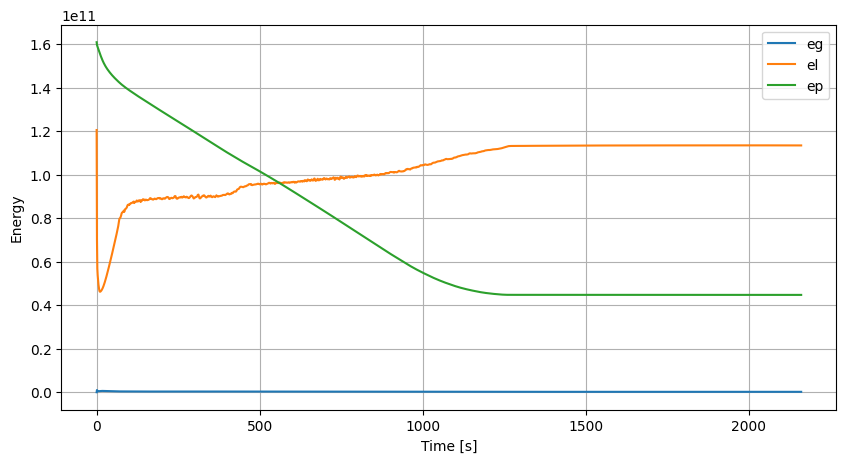

In [48]:
plt.figure(figsize=(10, 5))

plt.plot(
    balance["time"],
    balance["eg"],
    label="eg"
)

plt.plot(
    balance["time"],
    balance["el"],
    label="el"
)

plt.plot(
    balance["time"],
    balance["ep"],
    label="ep"
)

plt.xlabel("Time [s]")
plt.ylabel("Energy")
plt.legend()
plt.grid(True)

plt.show()

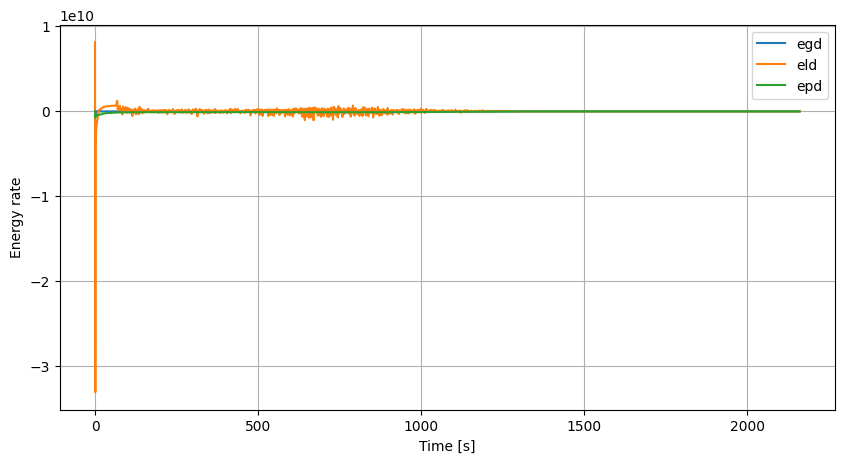

In [49]:
plt.figure(figsize=(10, 5))

plt.plot(balance["time"], balance["egd"], label="egd")
plt.plot(balance["time"], balance["eld"], label="eld")
plt.plot(balance["time"], balance["epd"], label="epd")

plt.xlabel("Time [s]")
plt.ylabel("Energy rate")
plt.legend()
plt.grid(True)

plt.show()

In [50]:
print(temperature["particle_id"].nunique())
print(temperature["time"].nunique())
print(temperature.groupby("time").size().describe())

806
213
count    213.0
mean     806.0
std        0.0
min      806.0
25%      806.0
50%      806.0
75%      806.0
max      806.0
dtype: float64


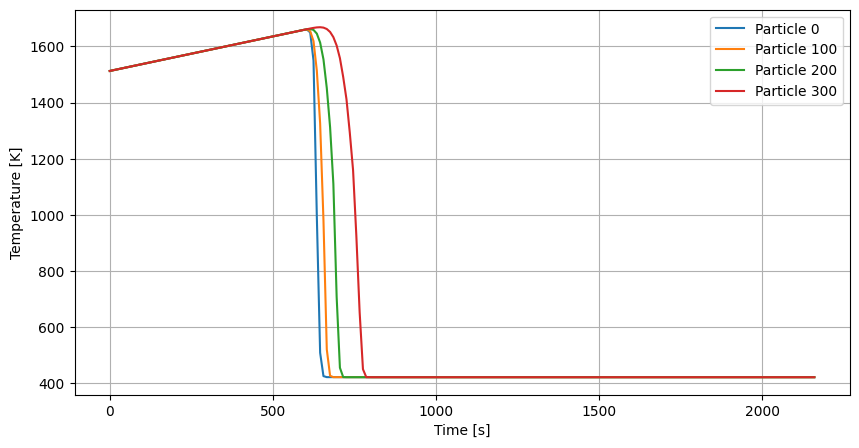

In [51]:
particle_ids = [0, 100, 200, 300]

plt.figure(figsize=(10, 5))

for pid in particle_ids:

    particle = temperature[
        temperature["particle_id"] == pid
    ]

    plt.plot(
        particle["time"],
        particle["temperature"],
        label=f"Particle {pid}"
    )

plt.xlabel("Time [s]")
plt.ylabel("Temperature [K]")
plt.legend()
plt.grid(True)

plt.show()

In [53]:
print(balance["time"].nunique())
print(balance["time"].min(), balance["time"].max())
print(balance["time"].diff().describe())

1879
0.001 2161.0033
count    1878.000000
mean        1.150693
std         0.166397
min         1.000200
25%         1.042832
50%         1.100300
75%         1.189560
max         2.191760
Name: time, dtype: float64


In [54]:
particle_times = (
    temperature["time"]
    .drop_duplicates()
    .sort_values()
)

print(len(particle_times))
print(particle_times.min(), particle_times.max())
print(particle_times.diff().describe())

213
0.001 2159.54
count    212.000000
mean      10.186505
std        0.246809
min       10.000000
25%       10.050000
50%       10.100000
75%       10.207750
max       11.320000
Name: time, dtype: float64


In [55]:
balance.describe().T[
    ["mean", "std", "min", "max"]
]

,mean,std,min,max
time,1.107951e+03,6.080465e+02,1.000000e-03,2.161003e+03
dt,3.512139e-01,3.399235e-01,1.000000e-03,1.663120e+00
mg,1.137404e+02,1.555442e+01,1.771120e+01,2.469109e+02
mgd,-6.211097e-02,2.785837e+00,-1.127152e+02,8.724050e+00
ml,1.703328e+05,1.956164e+04,7.630581e+04,1.988720e+05
...,...,...,...,...
erreli,-8.694229e+06,4.389922e+06,-1.341682e+07,-8.398455e+03
errel,-8.907606e+03,1.949758e+05,-8.398455e+06,2.143682e+05
errepi,3.392589e+06,1.229020e+06,-7.799600e-01,4.465590e+06
errep,2.163406e+03,7.492704e+03,-4.178235e+04,1.207907e+05


In [56]:
balance.std(numeric_only=True).sort_values().head(20)

mpd       0.0
mlay      0.0
mdd       0.0
md        0.0
mcd       0.0
mc        0.0
mmd       0.0
mm        0.0
mlayd     0.0
emd       0.0
ed        0.0
edd       0.0
elay      0.0
elayd     0.0
ecd       0.0
ec        0.0
fgini     0.0
fgin      0.0
em        0.0
qdouti    0.0
dtype: float64

In [57]:
balance.std(numeric_only=True).sort_values(ascending=False).head(20)

qgouti    5.920864e+10
qlini     5.331147e+10
qsii      4.188278e+10
ep        3.244091e+10
qlouti    3.121070e+10
powi      1.593550e+10
el        1.212241e+10
qsgi      5.424077e+09
eld       8.149655e+08
qlout     7.788253e+08
qlii      6.363521e+08
qdii      3.321960e+08
qlin      2.260282e+08
qgout     7.809763e+07
eg        7.153404e+07
epd       6.113474e+07
qsi       4.658566e+07
qsg       1.681451e+07
egd       1.061973e+07
erregi    7.470965e+06
dtype: float64

m corium is essentially constant

## Duration Prediction Baseline

As a first prediction task, the simulation duration was modeled using the static input parameters of each simulation.

The dataset initially contained 5000 simulations. Simulations with fewer than 10 timesteps were removed because such short trajectories do not contain sufficient temporal information for meaningful time-series modeling. This resulted in 4945 simulations.

The simulations were divided into training, validation, and test sets at the **simulation level**, rather than at the individual timestep level. The split was stratified according to trajectory length to ensure that short and long simulations were represented in all three subsets.

### Input

The duration model uses the 15 static simulation parameters:

- Psys
- Ffuel
- Porosity
- Dparticle
- Alpha
- Rflat
- Tbed
- Decay
- Fstruct
- Rcake
- Topcake
- Botcake
- Porcake
- Partdiacake
- Hdebris

### Target

The target variable was defined as:

`log1p(sequence_length)`

The logarithmic transformation was used because the distribution of simulation lengths is strongly skewed, with a large concentration of simulations close to the maximum duration.

Two quantile regression models were trained:

- **P50 model:** predicts the median simulation length
- **P75 model:** predicts the 75th percentile of simulation length

### Results

#### P50 model

- MAE in log space: **0.275**
- RMSE in log space: **0.449**
- MAE in original sequence length: **92.6 timesteps**
- P50 coverage: **50.7%**
- Median absolute percentage error (MdAPE): **16.3%**

#### P75 model

- MAE in log space: **0.316**
- MAE in original sequence length: **95.8 timesteps**
- P75 coverage: **68.9%**
- Median absolute percentage error (MdAPE): **14.6%**

The P50 model is well calibrated, with approximately 50% of the actual sequence lengths falling below the predicted P50 value. The P75 model currently underestimates the desired 75% coverage, achieving approximately 69%.

### Dependence on Simulation Duration

The prediction error was also evaluated for different ranges of actual sequence length.

| Actual sequence length | Number of cases | MAE [timesteps] | MdAPE |
|---|---:|---:|---:|
| 0–50 | 24 | 45.8 | 66.6% |
| 50–100 | 33 | 115.3 | 70.9% |
| 100–200 | 49 | 82.5 | 29.4% |
| 200–300 | 32 | 85.6 | 21.5% |
| 300–500 | 75 | 80.0 | 17.4% |
| 500–650 | 66 | 103.3 | 14.7% |
| 650–750 | 216 | 98.8 | 8.2% |

The model performs considerably better in relative terms for long simulations. The MdAPE decreases from approximately 67–71% for simulations shorter than 100 timesteps to only 8.2% for simulations between 650 and 750 timesteps.

The large relative errors for short simulations are partly caused by the sensitivity of relative error to small target values. For example, an absolute error of 50 timesteps corresponds to a 100% relative error for a 50-timestep simulation, but only about 7% for a 700-timestep simulation.

Overall, the duration prediction task appears to be **learnable from the static simulation parameters**, although short-duration and early-terminating simulations remain considerably more difficult to predict accurately.

This provides a baseline for the next stage of the workflow: **prediction of the maximum simulation time**.

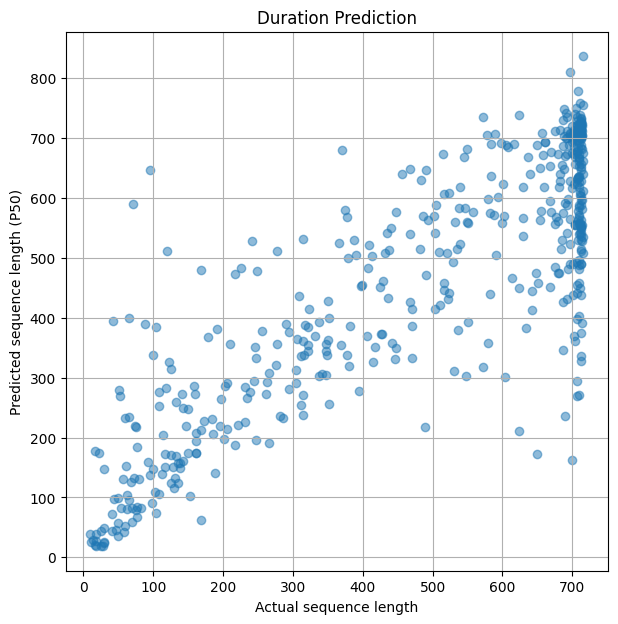

In [5]:
results = pd.read_csv(
    DATA_DIR/"processed/duration_predictions.csv"
)

plt.figure(figsize=(7, 7))

plt.scatter(
    results["sequence_length"],
    results["predicted_length_p50"],
    alpha=0.5
)

plt.xlabel("Actual sequence length")
plt.ylabel("Predicted sequence length (P50)")
plt.title("Duration Prediction")

plt.grid(True)
plt.show()

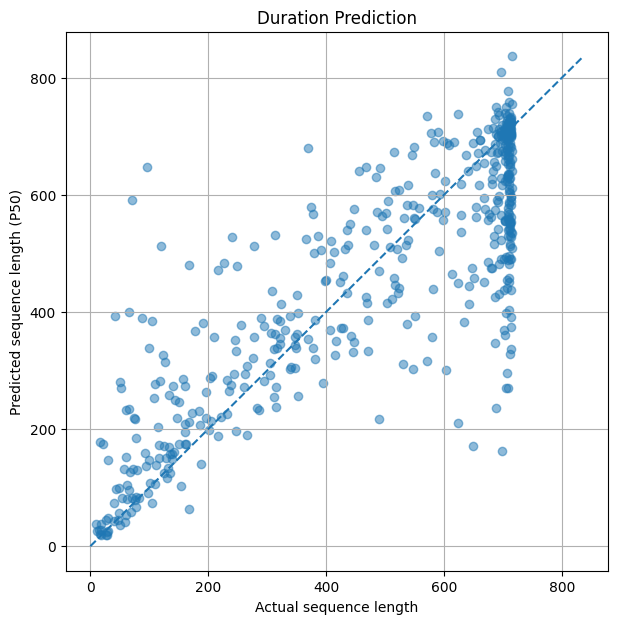

In [6]:
max_value = max(
    results["sequence_length"].max(),
    results["predicted_length_p50"].max()
)

plt.figure(figsize=(7, 7))

plt.scatter(
    results["sequence_length"],
    results["predicted_length_p50"],
    alpha=0.5
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual sequence length")
plt.ylabel("Predicted sequence length (P50)")
plt.title("Duration Prediction")

plt.grid(True)
plt.show()

In [7]:
metadata = pd.read_csv(
    DATA_DIR/ "processed/simulation_metadata_7200_clean.csv"
)

splits = pd.read_csv(
    DATA_DIR/ "processed/simulation_splits.csv"
)

print("Clean metadata:", len(metadata))
print("Split file:", len(splits))

print(
    "Metadata IDs:",
    metadata["Simulation No"].nunique()
)

print(
    "Split IDs:",
    splits["Simulation No"].nunique()
)

print(
    "Missing from splits:",
    set(metadata["Simulation No"]) - set(splits["Simulation No"])
)

print(
    "Extra in splits:",
    set(splits["Simulation No"]) - set(metadata["Simulation No"])
)

Clean metadata: 4945
Split file: 4945
Metadata IDs: 4945
Split IDs: 4945
Missing from splits: set()
Extra in splits: set()


In [8]:
coverage_p75 = (
    results["sequence_length"]
    <= results["predicted_length_p75"]
).mean()

print(f"P75 coverage: {coverage_p75:.3f}")

P75 coverage: 0.689


In [9]:
coverage_p50 = (
    results["sequence_length"]
    <= results["predicted_length_p50"]
).mean()

print(f"P50 coverage: {coverage_p50:.3f}")

P50 coverage: 0.507


In [10]:
#find the worst predictions
results.sort_values(
    "relative_error_p50",
    ascending=False
)[
    [
        "Simulation No",
        "sequence_length",
        "predicted_length_p50",
        "predicted_length_p75",
        "relative_error_p50",
    ]
].head(20)

,Simulation No,sequence_length,predicted_length_p50,predicted_length_p75,relative_error_p50
360,3710,16,177.639319,172.424496,10.102457
234,2374,42,393.921385,342.695215,8.379081
16,135,71,590.584889,474.131699,7.318097
488,4949,22,174.819146,294.501825,6.946325
438,4424,96,647.301150,685.875557,5.742720
44,501,65,400.327537,379.729146,5.158885
241,2445,51,279.979309,227.131125,4.489790
482,4908,52,269.518201,189.915451,4.183042
222,2232,30,146.729880,171.561625,3.890996
66,688,88,389.775283,313.090077,3.429265


In [11]:
results.sort_values(
    "relative_error_p75",
    ascending=False
)[
    [
        "Simulation No",
        "sequence_length",
        "predicted_length_p50",
        "predicted_length_p75",
        "relative_error_p75",
    ]
].head(20)

,Simulation No,sequence_length,predicted_length_p50,predicted_length_p75,relative_error_p75
488,4949,22,174.819146,294.501825,12.386447
360,3710,16,177.639319,172.424496,9.776531
359,3708,10,38.367785,87.540790,7.754079
234,2374,42,393.921385,342.695215,7.159410
438,4424,96,647.301150,685.875557,6.144537
153,1552,61,153.059780,416.307365,5.824711
16,135,71,590.584889,474.131699,5.677911
44,501,65,400.327537,379.729146,4.841987
222,2232,30,146.729880,171.561625,4.718721
61,662,18,38.666287,102.343554,4.685753


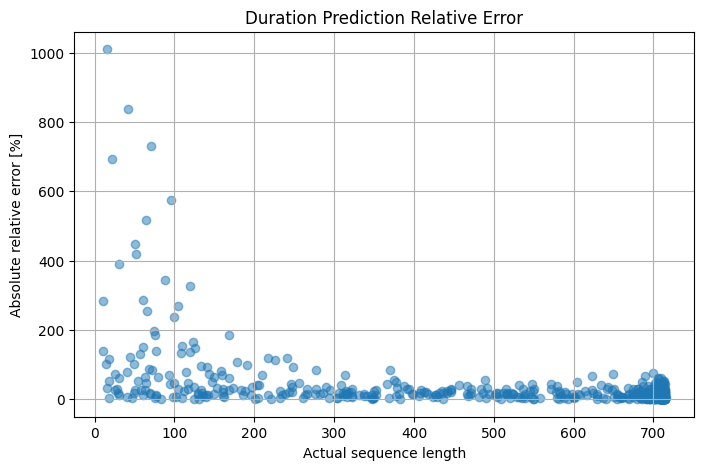

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    results["sequence_length"],
    results["relative_error_p50"] * 100,
    alpha=0.5
)

plt.xlabel("Actual sequence length")
plt.ylabel("Absolute relative error [%]")
plt.title("Duration Prediction Relative Error")

plt.grid(True)
plt.show()

the biggest relative errors are <b> strongly concentrated at short sequence lengths </b>
For simulations with:

- sequence_length < 100: relative errors can exceed 1000%
- sequence_length ≈ 100–200: errors are generally much smaller, but there are still some large outliers
- sequence_length > 300: most errors are roughly <100%
- sequence_length ≈ 700: the majority are relatively close to zero

So the huge mean relative error of 39.1% is <b> not representative of the model's performance across the majority of the dataset </b> . It is being driven heavily by the short-duration simulations.

an important thing we learned from this:
<b> Duration prediction is substantially more difficult for early-terminating simulations than for simulations approaching the maximum runtime.</b>

In [13]:
bins = [0, 50, 100, 200, 300, 500, 650, 750]

results["duration_bin"] = pd.cut(
    results["sequence_length"],
    bins=bins
)

grouped = results.groupby(
    "duration_bin",
    observed=True
)

summary = grouped.apply(
    lambda x: pd.Series({
        "N": len(x),
        "MAE": np.mean(
            np.abs(
                x["predicted_length_p50"]
                - x["sequence_length"]
            )
        ),
        "MdAPE": np.median(
            np.abs(
                x["predicted_length_p50"]
                - x["sequence_length"]
            )
            / x["sequence_length"]
        ) * 100,
    })
)

summary

/tmp/ipykernel_1294147/3168229087.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = grouped.apply(


,N,MAE,MdAPE
duration_bin,,,
"(0, 50]",24.0,45.827602,66.571825
"(50, 100]",33.0,115.329998,70.910854
"(100, 200]",49.0,82.509304,29.436557
"(200, 300]",32.0,85.560711,21.515953
"(300, 500]",75.0,80.035656,17.370438
"(500, 650]",66.0,103.279291,14.741214
"(650, 750]",216.0,98.801367,8.191219


In [23]:
metadata_clean = metadata[
    metadata["sequence_length"] >= MIN_SEQUENCE_LEN
].copy()
metadata_clean["maximum_time"].describe()

count    4945.000000
mean     4882.221260
std      2532.582281
min        91.051800
25%      2441.390000
50%      5944.440000
75%      7194.170000
max      7200.000000
Name: maximum_time, dtype: float64

In [16]:
print("Shortest simulations:")
print(
    metadata_clean[
        ["Simulation No", "maximum_time", "sequence_length"]
    ]
    .sort_values("maximum_time")
    .head(20)
)

print("\nLongest simulations:")
print(
    metadata_clean[
        ["Simulation No", "maximum_time", "sequence_length"]
    ]
    .sort_values("maximum_time", ascending=False)
    .head(20)
)

Shortest simulations:
      Simulation No  maximum_time  sequence_length
260             263       91.0518               10
1207           1228       91.0847               10
2923           2959       91.3200               10
3703           3746       91.9279               10
3666           3708       93.1302               10
1288           1310       93.3117               10
4903           4958       93.5732               10
2657           2688       95.3302               10
2554           2583      101.7030               11
1065           1086      101.9980               11
4603           4653      104.1880               11
2341           2368      104.3640               11
734             744      105.3340               11
3419           3460      106.7380               11
4410           4458      114.5660               12
4374           4421      115.3560               12
1856           1881      116.8690               12
2703           2734      117.0540               12
1983     

In [17]:
for threshold in [7000, 7100, 7150, 7190, 7199]:
    count = (
        metadata_clean["maximum_time"] >= threshold
    ).sum()

    percentage = (
        count / len(metadata_clean) * 100
    )

    print(
        f">= {threshold} s: "
        f"{count} simulations "
        f"({percentage:.2f}%)"
    )

>= 7000 s: 2112 simulations (42.71%)
>= 7100 s: 2082 simulations (42.10%)
>= 7150 s: 2066 simulations (41.78%)
>= 7190 s: 2056 simulations (41.58%)
>= 7199 s: 243 simulations (4.91%)


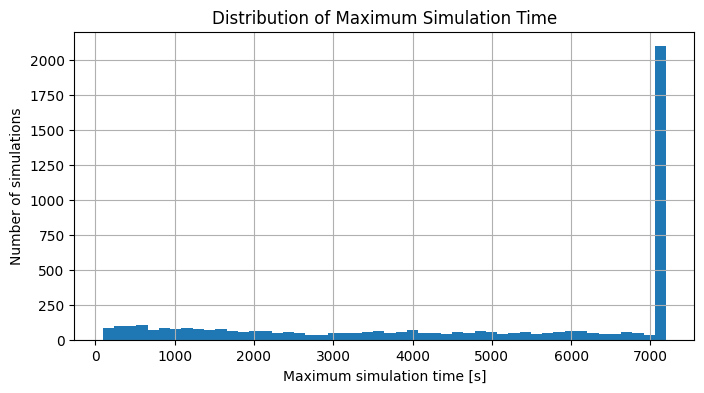

In [18]:
plt.figure(figsize=(8, 4))

plt.hist(
    metadata_clean["maximum_time"],
    bins=50
)

plt.xlabel("Maximum simulation time [s]")
plt.ylabel("Number of simulations")
plt.title("Distribution of Maximum Simulation Time")

plt.grid(True)
plt.show()

## Maximum Simulation Time Prediction

The second prediction task was to predict the **maximum physical simulation time** from the 15 static input parameters of each simulation.

Unlike `sequence_length`, which represents the number of recorded simulation states, `maximum_time` represents the actual physical time corresponding to the final recorded state. No fixed relationship between the number of states and physical time was assumed, since the simulation time intervals are not uniform.

### Input

The same 15 static simulation parameters used for sequence-length prediction were used:

- Psys
- Ffuel
- Porosity
- Dparticle
- Alpha
- Rflat
- Tbed
- Decay
- Fstruct
- Rcake
- Topcake
- Botcake
- Porcake
- Partdiacake
- Hdebris

### Target

The target variable was defined as:

`log1p(maximum_time)`

The logarithmic transformation was used to reduce the effect of the strongly skewed distribution of simulation times.

Two quantile regression models were trained:

- **P50 model:** predicts the median maximum simulation time
- **P75 model:** predicts the 75th percentile of maximum simulation time

### Results

#### P50 model

- MAE in log space: **0.280**
- RMSE in log space: **0.468**
- MAE in original scale: **961.4 s**
- P50 coverage: **52.3%**
- MdAPE: **16.0%**

#### P75 model

- MAE in log space: **0.353**
- RMSE in log space: **0.644**
- MAE in original scale: **1049.1 s**
- P75 coverage: **70.3%**
- MdAPE: **15.1%**

The P50 model is reasonably well calibrated, with 52.3% of the actual maximum simulation times falling below the predicted P50 value. The P75 model currently underestimates the desired 75% coverage, achieving approximately 70.3%.

### Dependence on Simulation Time

The prediction error was evaluated for different ranges of actual maximum simulation time.

| Actual maximum time [s] | Number of cases | MAE [s] | MdAPE |
|---|---:|---:|---:|
| 0–1000 | 53 | 788.6 | 75.3% |
| 1000–2000 | 52 | 1052.3 | 29.2% |
| 2000–3000 | 33 | 865.1 | 23.6% |
| 3000–4000 | 39 | 682.0 | 13.5% |
| 4000–5000 | 32 | 994.1 | 21.0% |
| 5000–6000 | 42 | 943.7 | 15.6% |
| 6000–6500 | 20 | 947.6 | 7.9% |
| 6500–7000 | 21 | 1363.2 | 18.5% |
| 7000–7500 | 203 | 1010.9 | 9.3% |

The model performs considerably better in relative terms for long-running simulations. The MdAPE decreases from **75.3%** for simulations below 1000 s to **9.3%** for simulations between 7000 and 7500 s.

The absolute errors remain on the order of several hundred to approximately 1000 s across most duration ranges. Therefore, the large relative errors at short simulation times are partly caused by the smaller denominator in the relative-error calculation.

### Key Observation

A large fraction of the simulations run close to the 7200 s upper simulation limit. These long-running simulations are predicted relatively well, while early-terminating simulations are considerably more difficult to predict.

This suggests that the simulation population may contain different prediction regimes:

```text
Static input parameters
        |
        v
+-------------------------+
| Simulation termination  |
| behaviour               |
+------------+------------+
             |
       +-----+-----+
       |           |
       v           v
 Long-running   Early termination
 simulations    simulations
       |           |
       v           v
 ~7200 s       variable duration

In [25]:
maximum_time_results = pd.read_csv(
    DATA_DIR/"processed/maximum_time_predictions.csv"
)

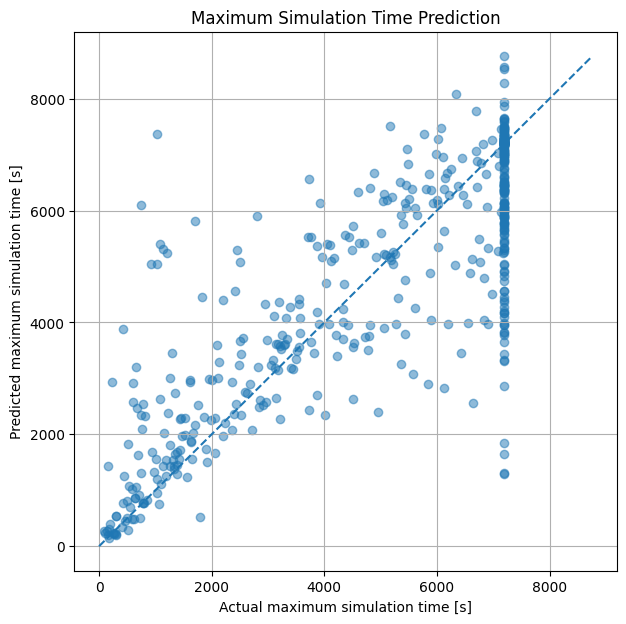

In [26]:
plt.figure(figsize=(7, 7))

plt.scatter(
    maximum_time_results["maximum_time"],
    maximum_time_results["predicted_maximum_time_p50"],
    alpha=0.5
)

max_value = max(
    maximum_time_results["maximum_time"].max(),
    maximum_time_results["predicted_maximum_time_p50"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual maximum simulation time [s]")
plt.ylabel("Predicted maximum simulation time [s]")
plt.title("Maximum Simulation Time Prediction")

plt.grid(True)
plt.show()

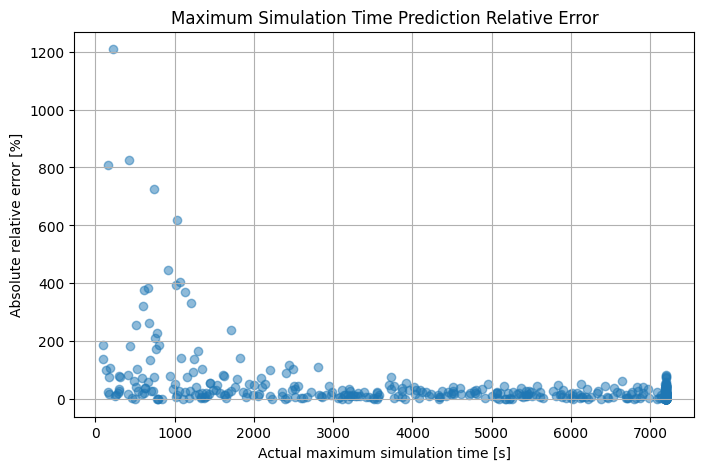

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(
    maximum_time_results["maximum_time"],
    maximum_time_results["relative_error_p50"] * 100,
    alpha=0.5
)

plt.xlabel("Actual maximum simulation time [s]")
plt.ylabel("Absolute relative error [%]")
plt.title("Maximum Simulation Time Prediction Relative Error")

plt.grid(True)
plt.show()

In [28]:
bins = [
    0,
    1000,
    2000,
    3000,
    4000,
    5000,
    6000,
    6500,
    7000,
    7500
]

maximum_time_results["time_bin"] = pd.cut(
    maximum_time_results["maximum_time"],
    bins=bins
)

grouped = maximum_time_results.groupby(
    "time_bin",
    observed=True
)

summary = grouped.apply(
    lambda x: pd.Series({
        "N": len(x),
        "MAE": np.mean(
            np.abs(
                x["predicted_maximum_time_p50"]
                - x["maximum_time"]
            )
        ),
        "MdAPE": np.median(
            np.abs(
                x["predicted_maximum_time_p50"]
                - x["maximum_time"]
            )
            / x["maximum_time"]
        ) * 100,
    })
)

summary

/tmp/ipykernel_1294147/2806790813.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = grouped.apply(


,N,MAE,MdAPE
time_bin,,,
"(0, 1000]",53.0,788.603316,75.316883
"(1000, 2000]",52.0,1052.301354,29.246584
"(2000, 3000]",33.0,865.103665,23.567551
"(3000, 4000]",39.0,681.964871,13.549110
"(4000, 5000]",32.0,994.077125,20.978146
"(5000, 6000]",42.0,943.703990,15.626138
"(6000, 6500]",20.0,947.625553,7.919773
"(6500, 7000]",21.0,1363.234065,18.549756
"(7000, 7500]",203.0,1010.889206,9.263441


## Exploration of the temp file

In [23]:
temp = pd.read_csv(
    "/home/ikeaprash/project/data/7200 sec Run/00012.00012.temp_unwrapped.csv"
)

print(temp.shape)
print(temp.head())
print(temp.dtypes)

(658880, 6)
    time  particle_id        x    y        z  temperature
0  0.001            0  0.05088  0.0  0.01875      1083.15
1  0.001            1  0.15260  0.0  0.01875      1083.15
2  0.001            2  0.25440  0.0  0.01875      1083.15
3  0.001            3  0.35630  0.0  0.01875      1083.15
4  0.001            4  0.45810  0.0  0.01875      1083.15
time           float64
particle_id      int64
x              float64
y              float64
z              float64
temperature    float64
dtype: object


In [24]:
print("Number of particles:")
print(temp["particle_id"].nunique())

print("\nTime points:")
print(temp["time"].nunique())

print("\nTime range:")
print(temp["time"].min(), temp["time"].max())

Number of particles:
928

Time points:
710

Time range:
0.001 7191.77


In [25]:
particle_counts = (
    temp.groupby("particle_id")["time"]
    .nunique()
)

print(particle_counts.describe())

count    928.0
mean     710.0
std        0.0
min      710.0
25%      710.0
50%      710.0
75%      710.0
max      710.0
Name: time, dtype: float64


In [26]:
print(
    particle_counts.value_counts().sort_index()
)

time
710    928
Name: count, dtype: int64


### check whether particles move

In [27]:
for pid in temp["particle_id"].unique()[:5]:

    p = temp[temp["particle_id"] == pid]

    print(
        f"Particle {pid}:",
        "x range =", p["x"].min(), p["x"].max(),
        "y range =", p["y"].min(), p["y"].max(),
        "z range =", p["z"].min(), p["z"].max()
    )

Particle 0: x range = 0.05088 0.05088 y range = 0.0 0.0 z range = 0.01875 0.01875
Particle 1: x range = 0.1526 0.1526 y range = 0.0 0.0 z range = 0.01875 0.01875
Particle 2: x range = 0.2544 0.2544 y range = 0.0 0.0 z range = 0.01875 0.01875
Particle 3: x range = 0.3563 0.3563 y range = 0.0 0.0 z range = 0.01875 0.01875
Particle 4: x range = 0.4581 0.4581 y range = 0.0 0.0 z range = 0.01875 0.01875


### check particle IDs

In [28]:
print(
    temp["particle_id"].min(),
    temp["particle_id"].max()
)

print(
    temp["particle_id"].nunique()
)

0 927
928


In [29]:
print(
    temp.groupby("particle_id")[["x", "y", "z"]]
    .first()
    .head(20)
)

                   x    y        z
particle_id                       
0            0.05088  0.0  0.01875
1            0.15260  0.0  0.01875
2            0.25440  0.0  0.01875
3            0.35630  0.0  0.01875
4            0.45810  0.0  0.01875
5            0.56010  0.0  0.01875
6            0.66220  0.0  0.01875
7            0.76430  0.0  0.01875
8            0.86650  0.0  0.01875
9            0.96870  0.0  0.01875
10           1.07100  0.0  0.01875
11           1.17300  0.0  0.01875
12           1.27600  0.0  0.01875
13           1.37800  0.0  0.01875
14           1.48000  0.0  0.01875
15           1.58200  0.0  0.01875
16           1.68500  0.0  0.01875
17           1.78700  0.0  0.01875
18           1.88900  0.0  0.01875
19           1.99100  0.0  0.01875


In [30]:
position_variation = (
    temp.groupby("particle_id")[["x", "y", "z"]]
    .agg(lambda x: x.max() - x.min())
)

print(position_variation.describe())

           x      y      z
count  928.0  928.0  928.0
mean     0.0    0.0    0.0
std      0.0    0.0    0.0
min      0.0    0.0    0.0
25%      0.0    0.0    0.0
50%      0.0    0.0    0.0
75%      0.0    0.0    0.0
max      0.0    0.0    0.0


In [31]:
print("\nMaximum movement:")
print(position_variation.max())

print("\nParticles with largest x movement:")
print(
    position_variation["x"]
    .sort_values(ascending=False)
    .head(20)
)


Maximum movement:
x    0.0
y    0.0
z    0.0
dtype: float64

Particles with largest x movement:
particle_id
911    0.0
910    0.0
909    0.0
908    0.0
907    0.0
906    0.0
905    0.0
904    0.0
903    0.0
902    0.0
901    0.0
900    0.0
899    0.0
898    0.0
897    0.0
896    0.0
31     0.0
30     0.0
29     0.0
28     0.0
Name: x, dtype: float64


In [32]:
print("\nNumber of particles with movement:")

print(
    "x:",
    (position_variation["x"] > 1e-10).sum()
)

print(
    "y:",
    (position_variation["y"] > 1e-10).sum()
)

print(
    "z:",
    (position_variation["z"] > 1e-10).sum()
)


Number of particles with movement:
x: 0
y: 0
z: 0


### check time spacing

In [33]:
times = (
    temp["time"]
    .drop_duplicates()
    .sort_values()
)

dt = times.diff().dropna()

print(dt.describe())

count    709.000000
mean      10.143539
std        0.147020
min       10.000000
25%       10.060000
50%       10.120000
75%       10.185000
max       11.549000
Name: time, dtype: float64


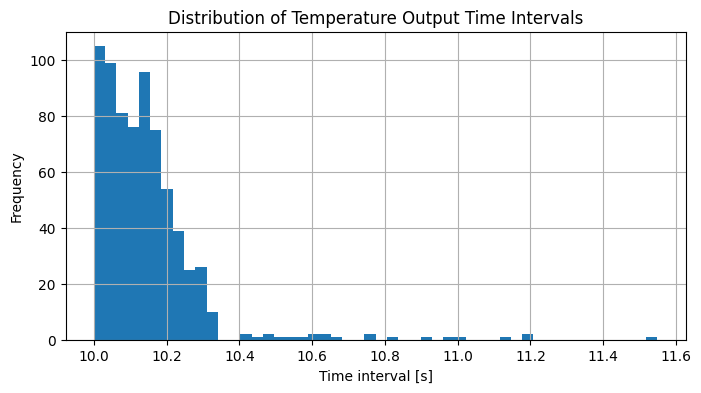

In [34]:
plt.figure(figsize=(8,4))

plt.hist(dt, bins=50)

plt.xlabel("Time interval [s]")
plt.ylabel("Frequency")
plt.title("Distribution of Temperature Output Time Intervals")

plt.grid(True)
plt.show()

### temp dist

In [35]:
temp["temperature"].describe()

count    658880.000000
mean        506.318319
std         252.578263
min         418.564000
25%         419.557000
50%         420.009000
75%         420.274000
max        2251.370000
Name: temperature, dtype: float64

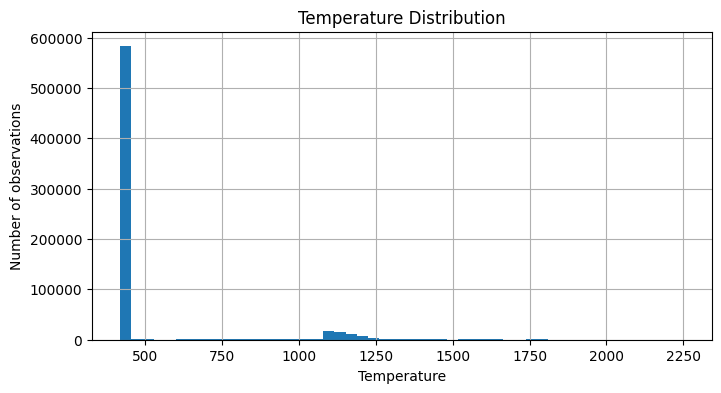

In [36]:
plt.figure(figsize=(8,4))

plt.hist(
    temp["temperature"],
    bins=50
)

plt.xlabel("Temperature")
plt.ylabel("Number of observations")
plt.title("Temperature Distribution")

plt.grid(True)
plt.show()

In [37]:
print(temp.shape)

print("Particles:", temp["particle_id"].nunique())
print("Time points:", temp["time"].nunique())
print("Time range:", temp["time"].min(), temp["time"].max())

particle_counts = (
    temp.groupby("particle_id")["time"].nunique()
)

print("\nParticle timestep counts:")
print(particle_counts.describe())

times = (
    temp["time"]
    .drop_duplicates()
    .sort_values()
)

dt = times.diff().dropna()

print("\nTime interval statistics:")
print(dt.describe())

print("\nTemperature:")
print(temp["temperature"].describe())

(658880, 6)
Particles: 928
Time points: 710
Time range: 0.001 7191.77

Particle timestep counts:
count    928.0
mean     710.0
std        0.0
min      710.0
25%      710.0
50%      710.0
75%      710.0
max      710.0
Name: time, dtype: float64

Time interval statistics:
count    709.000000
mean      10.143539
std        0.147020
min       10.000000
25%       10.060000
50%       10.120000
75%       10.185000
max       11.549000
Name: time, dtype: float64

Temperature:
count    658880.000000
mean        506.318319
std         252.578263
min         418.564000
25%         419.557000
50%         420.009000
75%         420.274000
max        2251.370000
Name: temperature, dtype: float64


In [38]:
for pid in temp["particle_id"].unique()[:5]:

    p = temp[temp["particle_id"] == pid]

    print(
        f"Particle {pid}:",
        f"x: {p['x'].min():.4f} → {p['x'].max():.4f},",
        f"y: {p['y'].min():.4f} → {p['y'].max():.4f},",
        f"z: {p['z'].min():.4f} → {p['z'].max():.4f}"
    )

Particle 0: x: 0.0509 → 0.0509, y: 0.0000 → 0.0000, z: 0.0187 → 0.0187
Particle 1: x: 0.1526 → 0.1526, y: 0.0000 → 0.0000, z: 0.0187 → 0.0187
Particle 2: x: 0.2544 → 0.2544, y: 0.0000 → 0.0000, z: 0.0187 → 0.0187
Particle 3: x: 0.3563 → 0.3563, y: 0.0000 → 0.0000, z: 0.0187 → 0.0187
Particle 4: x: 0.4581 → 0.4581, y: 0.0000 → 0.0000, z: 0.0187 → 0.0187


In [60]:
import pandas as pd

metadata_clean = pd.read_csv(
    "/home/ikeaprash/project/data/processed/simulation_metadata_7200_clean.csv"
)

splits = pd.read_csv(
    "/home/ikeaprash/project/data/processed/simulation_splits.csv"
)

In [61]:
print(
    metadata_clean[
        [
            "Simulation No",
            "sequence_length",
            "maximum_time"
        ]
    ].describe()
)

       Simulation No  sequence_length  maximum_time
count    4945.000000      4945.000000   4945.000000
mean     2501.918301       477.560364   4882.221260
std      1442.305459       247.224021   2532.582281
min         0.000000        10.000000     91.051800
25%      1257.000000       241.000000   2441.390000
50%      2500.000000       583.000000   5944.440000
75%      3751.000000       706.000000   7194.170000
max      4999.000000       719.000000   7200.000000


## trajectory diags file exlporation

In [62]:
trajectory_diagnostics = pd.read_csv(
    "/home/ikeaprash/project/data/processed/trajectory_diagnostics.csv"
)

In [63]:
trajectory_diagnostics[
    [
        "n_particles",
        "n_time_points",
        "n_rows"
    ]
].describe()

,n_particles,n_time_points,n_rows
count,5000.000000,5000.000000,5.000000e+03
mean,728.900000,472.337200,3.512292e+05
std,209.536436,250.800104,2.254385e+05
min,259.000000,1.000000,3.360000e+02
25%,568.000000,228.000000,1.539840e+05
50%,708.000000,578.000000,3.482740e+05
75%,868.000000,706.000000,5.250375e+05
max,1529.000000,719.000000,1.035133e+06


In [64]:
print(
    trajectory_diagnostics[
        "n_particles"
    ].value_counts().sort_index()
)

n_particles
259     1
260     1
267     1
274     1
278     1
       ..
1409    1
1411    1
1422    1
1425    1
1529    1
Name: count, Length: 929, dtype: int64


In [65]:
print(
    trajectory_diagnostics[
        "n_time_points"
    ].value_counts().sort_index()
)

n_time_points
1      39
4       1
5       2
6       3
7       3
       ..
715    62
716    17
717    19
718     2
719     3
Name: count, Length: 705, dtype: int64


In [66]:
input_columns = [
    "Psys",
    "Ffuel",
    "Porosity",
    "Dparticle",
    "Alpha",
    "Rflat",
    "Tbed",
    "Decay",
    "Fstruct",
    "Rcake",
    "Topcake",
    "Botcake",
    "Porcake",
    "Partdiacake",
    "Hdebris",
]

print(metadata_clean[input_columns].head())
print()
print("Number of input parameters:", len(input_columns))
print()
print("Missing values:")
print(metadata_clean[input_columns].isna().sum())

       Psys    Ffuel  Porosity  Dparticle   Alpha   Rflat     Tbed     Decay  \
0  404411.0  0.82635  0.486025   0.003924  16.839  0.5230  1512.67  0.008307   
1  148571.0  0.86185  0.258825   0.002791  18.597  1.8034  1253.71  0.007041   
2  411275.0  0.91785  0.423075   0.003737  16.203  0.3646  1549.33  0.003242   
3  457139.0  0.97545  0.442825   0.002564  21.129  0.1818  1286.47  0.007395   
4  380153.0  0.93225  0.334175   0.001651  27.843  1.0550   488.53  0.003832   

    Fstruct     Rcake   Topcake   Botcake   Porcake  Partdiacake   Hdebris  
0  1.115375  0.122930  0.715806  0.488859  0.182432     0.000844  2.192350  
1  0.844125  1.142793  0.853430  0.716177  0.223470     0.001861  1.336405  
2  0.550125  0.248922  1.254117  0.696887  0.103698     0.003160  1.846595  
3  0.576375  0.185108  0.592630  0.413072  0.305848     0.000449  2.250654  
4  1.301575  0.436180  0.513966  0.466557  0.079846     0.000250  2.334949  

Number of input parameters: 15

Missing values:
Psys    

In [67]:
sim_id = 0

sim_metadata = metadata_clean[
    metadata_clean["Simulation No"] == sim_id
]

print(sim_metadata[input_columns].T)

                         0
Psys         404411.000000
Ffuel             0.826350
Porosity          0.486025
Dparticle         0.003924
Alpha            16.839000
Rflat             0.523000
Tbed           1512.670000
Decay             0.008307
Fstruct           1.115375
Rcake             0.122930
Topcake           0.715806
Botcake           0.488859
Porcake           0.182432
Partdiacake       0.000844
Hdebris           2.192350


In [68]:
temp = pd.read_csv(
    "/home/ikeaprash/project/data/7200 sec Run/"
    "00000.00000.temp_unwrapped.csv"
)

print(temp.head())
print(temp.columns.tolist())

    time  particle_id        x    y        z  temperature
0  0.001            0  0.06146  0.0  0.01369      1512.67
1  0.001            1  0.18280  0.0  0.01369      1512.67
2  0.001            2  0.30100  0.0  0.01369      1512.67
3  0.001            3  0.41630  0.0  0.01369      1512.67
4  0.001            4  0.52880  0.0  0.01369      1512.67
['time', 'particle_id', 'x', 'y', 'z', 'temperature']


## inspect dataset before training


In [5]:
import sys

print(sys.executable)

/home/ikeaprash/project/venv/bin/python


In [6]:
import pandas as pd

train = pd.read_parquet(
    "/home/ikeaprash/project/data/processed/trajectory_train.parquet"
)

print(train.shape)
print(train.head())
print(train.columns.tolist())

(1977800, 27)
   Simulation No  particle_id      Psys    Ffuel  Porosity  Dparticle   Alpha  \
0              0          555  404411.0  0.82635  0.486025   0.003924  16.839   
1              0          130  404411.0  0.82635  0.486025   0.003924  16.839   
2              0          740  404411.0  0.82635  0.486025   0.003924  16.839   
3              0          580  404411.0  0.82635  0.486025   0.003924  16.839   
4              0           91  404411.0  0.82635  0.486025   0.003924  16.839   

   Rflat     Tbed     Decay  ...       x    y        z      time    t_norm  \
0  0.523  1512.67  0.008307  ...  1.8520  0.0  1.12700  155.8680  0.072176   
1  0.523  1512.67  0.008307  ...  3.2060  0.0  0.10340   10.0606  0.004659   
2  0.523  1512.67  0.008307  ...  0.8526  0.0  1.65900  134.7750  0.062409   
3  0.523  1512.67  0.008307  ...  0.3010  0.0  1.21100  103.8270  0.048078   
4  0.523  1512.67  0.008307  ...  2.6280  0.0  0.07114  209.5540  0.097036   

   log1p_t_norm  sqrt_t_norm  

In [7]:
print(
    train.isna().sum()
)

Simulation No         0
particle_id           0
Psys                  0
Ffuel                 0
Porosity              0
Dparticle             0
Alpha                 0
Rflat                 0
Tbed                  0
Decay                 0
Fstruct               0
Rcake                 0
Topcake               0
Botcake               0
Porcake               0
Partdiacake           0
Hdebris               0
x                     0
y                     0
z                     0
time                  0
t_norm                0
log1p_t_norm          0
sqrt_t_norm           0
t_norm_squared        0
log1p_maximum_time    0
temperature           0
dtype: int64


In [8]:
print(
    train.dtypes
)

Simulation No           int64
particle_id             int64
Psys                  float64
Ffuel                 float64
Porosity              float64
Dparticle             float64
Alpha                 float64
Rflat                 float64
Tbed                  float64
Decay                 float64
Fstruct               float64
Rcake                 float64
Topcake               float64
Botcake               float64
Porcake               float64
Partdiacake           float64
Hdebris               float64
x                     float64
y                     float64
z                     float64
time                  float64
t_norm                float64
log1p_t_norm          float64
sqrt_t_norm           float64
t_norm_squared        float64
log1p_maximum_time    float64
temperature           float64
dtype: object


In [9]:
print(
    train["t_norm"].describe()
)

count    1.977800e+06
mean     4.999771e-01
std      2.891294e-01
min      1.388889e-07
25%      2.499661e-01
50%      5.000003e-01
75%      7.501257e-01
max      1.000000e+00
Name: t_norm, dtype: float64


In [10]:
print(
    train["temperature"].describe()
)

count    1.977800e+06
mean     7.702522e+02
std      5.725709e+02
min      3.762500e+02
25%      4.089287e+02
50%      4.229580e+02
75%      1.084870e+03
max      2.700010e+03
Name: temperature, dtype: float64


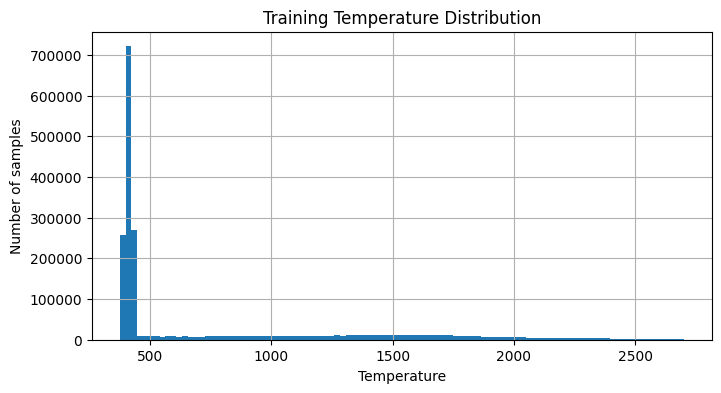

In [11]:
plt.figure(figsize=(8, 4))

plt.hist(
    train["temperature"],
    bins=100
)

plt.xlabel("Temperature")
plt.ylabel("Number of samples")
plt.title("Training Temperature Distribution")
plt.grid(True)
plt.show()

In [12]:
sim = train[
    train["Simulation No"] == 0
]

In [13]:
sim_id = train["Simulation No"].iloc[0]

sim = train[
    train["Simulation No"] == sim_id
]

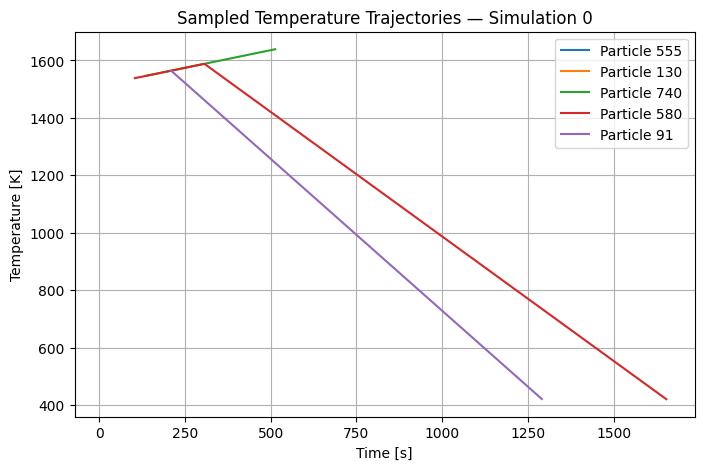

In [14]:
plt.figure(figsize=(8, 5))

for particle_id in sim["particle_id"].unique()[:5]:

    particle = sim[
        sim["particle_id"] == particle_id
    ].sort_values("time")

    plt.plot(
        particle["time"],
        particle["temperature"],
        label=f"Particle {particle_id}"
    )

plt.xlabel("Time [s]")
plt.ylabel("Temperature [K]")
plt.title(
    f"Sampled Temperature Trajectories — Simulation {sim_id}"
)

plt.grid(True)
plt.legend()
plt.show()

## temp_model exploration

At lower temperatures, predictions are broadly centered around the correct range. But as the actual temperature increases, the predictions increasingly fall below the diagonal.

The error plot makes this especially clear:

- Around 400–700 K, errors are relatively centered around zero.
- As temperature increases, the lower boundary of the errors moves strongly negative.
- At ~2000–2500 K, errors of roughly −1000 to −1500 K are common.

So the model is doing something like:

T_pred →conditional average temperature

rather than accurately reproducing the hot states.

This is classic regression-to-the-mean behavior, made worse by the very imbalanced target distribution we saw earlier.0

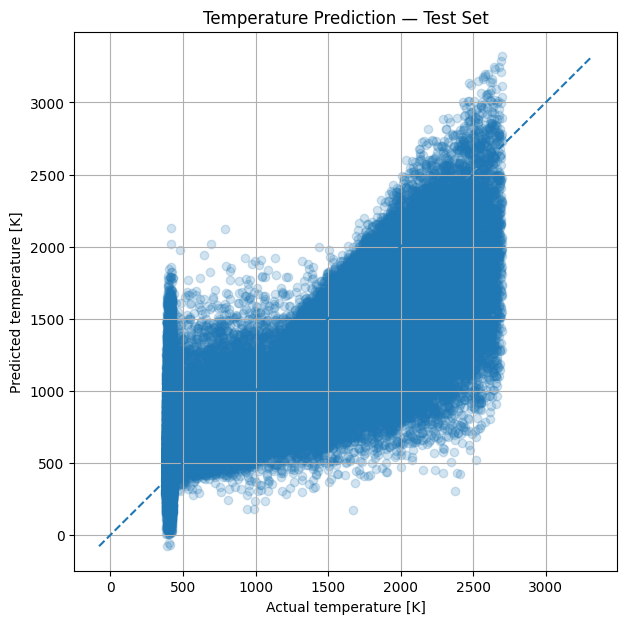

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

test_results = pd.read_parquet(
    "/home/ikeaprash/project/data/processed/"
    "predictions/temperature_predictions_test.parquet"
)

plt.figure(figsize=(7, 7))

plt.scatter(
    test_results["temperature"],
    test_results["prediction"],
    alpha=0.2
)

minimum = min(
    test_results["temperature"].min(),
    test_results["prediction"].min()
)

maximum = max(
    test_results["temperature"].max(),
    test_results["prediction"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual temperature [K]")
plt.ylabel("Predicted temperature [K]")
plt.title("Temperature Prediction — Test Set")
plt.grid(True)

plt.show()

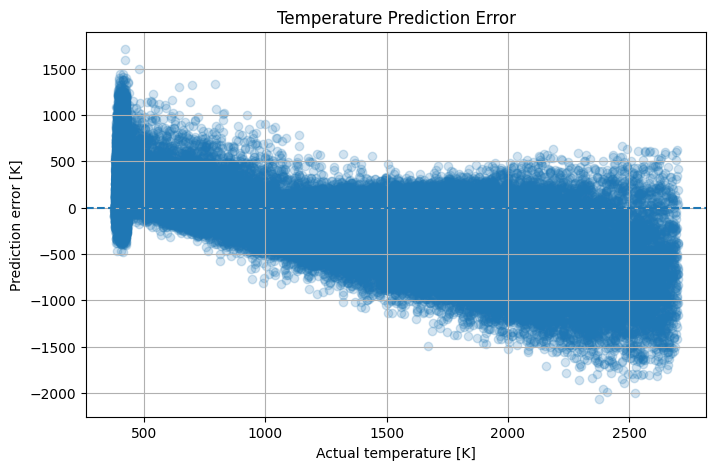

In [20]:
test_results["error"] = (
    test_results["prediction"]
    - test_results["temperature"]
)

plt.figure(figsize=(8, 5))

plt.scatter(
    test_results["temperature"],
    test_results["error"],
    alpha=0.2
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Actual temperature [K]")
plt.ylabel("Prediction error [K]")
plt.title("Temperature Prediction Error")
plt.grid(True)

plt.show()

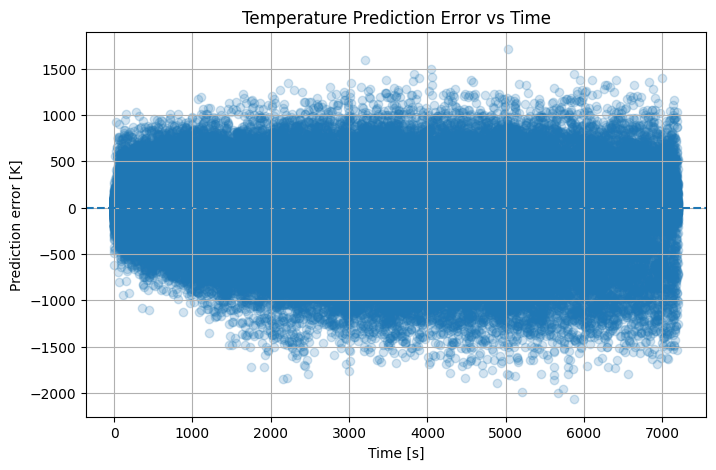

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    test_results["time"],
    test_results["error"],
    alpha=0.2
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Time [s]")
plt.ylabel("Prediction error [K]")
plt.title("Temperature Prediction Error vs Time")
plt.grid(True)

plt.show()

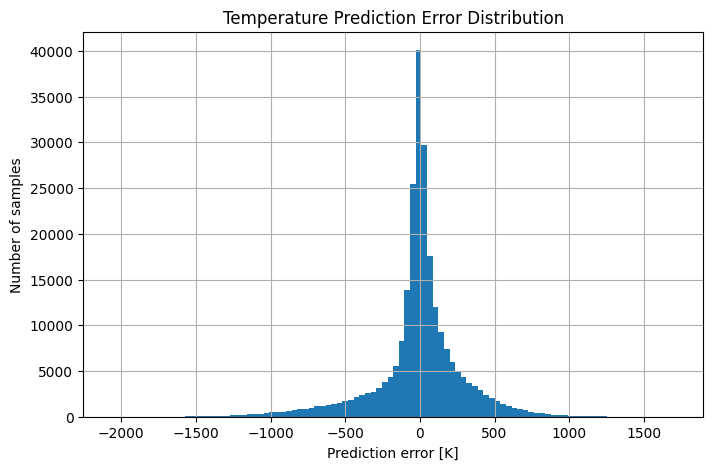

In [22]:
plt.figure(figsize=(8, 5))

plt.hist(
    test_results["error"],
    bins=100
)

plt.xlabel("Prediction error [K]")
plt.ylabel("Number of samples")
plt.title("Temperature Prediction Error Distribution")
plt.grid(True)

plt.show()